# [PBT] 화장품 이커머스 ㅣ 14. 교차검증 · 트리 비교 · 해석

## 이 노트북이 하는 일

**⑦ 일반화 + ⑧ 해석** — 보고서 Ⅳ-2 · Ⅴ 가 여기서 나온다.

> 묻는 것 : **이 모형이 새 데이터에서도 같은 성능을 낼 것인가**, 그리고 **계수를 어떻게 읽을 것인가**

```
13  적합 → 가정 검정 → 처방 → 민감도 → 성능      (13a~13l)
                    ─────────────────────
                    14  교차검증 → 트리 비교 → βstd·오즈비 → 프로파일링   ← 이 노트북
                    ─────────────────────
결과 보고서
```

설계행렬은 `13k`·`13l`(28열, 제곱항 반영)을 그대로 읽는다. **여기서 전처리를 다시 하지 않는다.**

## 여기서 하지 않는 것

| 안 하는 것 | 이유 |
|---|---|
| 전처리·재적합 | `12`·`13` 에서 끝났다. 다시 하면 두 벌이 갈린다 |
| 하이퍼파라미터 탐색 | 트리는 **"로지스틱이 놓친 구조가 있는가"를 재는 자**다. 튜닝해서 이기게 만들면 자가 아니게 된다 |
| 최종 모형 교체 | **결정 27번** — 성능이 좋다고 트리로 바꾸지 않는다 |
| 임계값 재선정 | `13` `#06-5` 에서 train F1 최대로 확정했다 (θ = 0.19) |
| 새 변수 추가 | `11` 이 확정한 X 6종 |

---

## 진입 전 확정된 것 — 결과를 보기 전에 정해져 있다

### 결정 25번 — 과적합 판정 기준 (분류용은 「교재 미기재」)

교재의 **Gap% 15% · Train R² 0.3** 은 **회귀 기준**이다. 분류용 합격선은 교재에 없다.
`my_ml.cls_overfit` 의 기본값(`threshold=0.15`)을 그대로 쓰되, 함수 자신이
*"threshold 는 학술 표준이 아닌 경험칙"* 이라 밝히므로 **AUC 절대차를 함께 본다.**

| 항목 | 기준 | 근거 |
|---|---|---|
| 과대적합 | Train↔CV **Gap% ≥ 15%** | `cls_overfit` 기본값 (교재 회귀 기준을 전용) |
| 과대적합 (절대차 병기) | Train − CV **AUC 차 ≥ 0.010** | test AUC 의 SE = **0.0049** 의 2배 (진단 §1) |
| 과소적합 | **train ROC-AUC < 0.60** | `cls_overfit` 기본값. AUC 0.5 = 동전 던지기 |

> ⚠️ **train AUC 가 0.5914 이므로 과소적합 판정이 나올 것을 알고 들어간다.**
> 이것은 함수의 결함이 아니라 사실이며, **우리 진단과 일치한다** —
> 모형이 복잡해서 못 맞히는 것이 아니라 **배울 것이 적어서** 못 맞힌다.

### 결정 26번 — 트리 비교 판정 규칙 (계획 보고서 §6 그대로)

| ΔAUC (트리 − 로지스틱) | 뜻 | 할 일 |
|---|---|---|
| **0.02 미만** | 선형으로 충분 | **로지스틱 확정.** 트리는 결과 보고서에 한 줄 |
| 0.02 ~ 0.05 | 비선형 구조가 조금 있다 | 어느 변수인지 보고 상호작용·구간화를 검토 |
| 0.05 초과 | 놓친 구조가 크다 | 변수 설계를 재검토하고 결과에 명시 |

**차이의 불확실성을 함께 낸다** — 같은 test 표본을 1,000회 재표집해 **짝지은 ΔAUC 의 95% 구간**을 구한다.
「교재 미기재」이므로 방법을 밝히고 쓴다. **유의성과 크기를 분리해 읽기 위해서다** —
표본이 크면 0.01 짜리 차이도 유의해지지만, 그것이 판정 기준 0.02 를 넘긴다는 뜻은 아니다.

### 결정 27번 — 최종 해석 모형은 로지스틱

계획 보고서 §1 의 질문이 *"어떤 조건이 기여하는가"* 이므로 **계수·오즈비로 답해야 한다.**
트리가 더 높은 AUC 를 내더라도 **최종 모형을 바꾸지 않는다.** 대신 그 격차를 한계에 적는다.

---

## ⚠️ helpers 주의 — 이 노트북에서 실제로 걸리는 것 5건

| # | 무엇 | 우리가 하는 일 |
|---|---|---|
| 1 | `cls_score` 계열은 **임계값 0.5 고정**이다. 우리 최대 예측확률이 0.526 이라 **F1·정밀도·재현율·MCC 가 전부 0** 으로 나온다 | `cls_compare_models` 의 `primary` 를 **`'ROC_AUC'` 로 바꾼다.** 기본값 `'F1'` 이면 전부 0 이라 순위가 매겨지지 않는다 |
| 2 | `cls_overfit` 의 `threshold=0.15` 는 **회귀 기준**이다 | 결정 25번대로 **AUC 절대차를 병기**한다 |
| 3 | `sklearn.LogisticRegression` 은 기본 `tol=1e-4` 라 statsmodels 와 **계수가 최대 0.055 어긋난다** | `solver='newton-cg', tol=1e-10` 으로 맞추고 **`#01-3` 에서 일치를 확인**한다 |
| 4 | `cls_baseline` 은 11종을 모두 돌려 **SVC 에서 매우 오래 걸린다** | `cls_baseline` 을 쓰지 않고 **트리 6종**(sklearn 3종 + `#01` 에서 설치한 xgboost · lightgbm · catboost)만 같은 설계행렬에 직접 적합한다 |
| 5 | `feature_importance` 는 트리 기준(MDI)이라 **분기 기회가 많은 연속형을 과대평가**한다 | 로지스틱의 βstd 순위와 **나란히 놓고 차이를 해석**한다. 어느 한쪽을 정답으로 삼지 않는다 |

## 👥 역할

| 셀 | 누가 |
|---|---|
| `#01`·`#02`·`#03`·`#05`·`#06`·`#08` | **만드는 사람** |
| `#04` 판정 · `#07` 검수 | **검수하는 사람** — 판정문을 읽고 서명한다 |

## 📐 수치 표기 규칙 (설계 §4-5)

> 판정문의 모든 수치에 **어느 셀에서 나오는지**를 `#03-1` 형태로 적는다.
> 앞 노트북의 파일에서 온 것은 `13f` 처럼 파일을 밝힌다. **둘 다 아닌 수치는 쓰지 않는다.**

---

## #01. 준비

In [1]:
import os, sys, warnings, time

# 프로젝트 폴더 — notebooks/ 안에서 실행하면 상위 폴더를 가리킨다
from pathlib import Path
BASE = str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd())
os.chdir(BASE)
sys.path.insert(0, BASE)

import numpy as np
from pandas import read_csv, read_parquet, DataFrame, Series, set_option, concat, cut
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from IPython.display import display, Markdown
import statsmodels.api as sm

from helpers import my_logit, my_ml, my_plot, RANDOM_STATE

set_option("display.max_columns", 60)
set_option("display.max_colwidth", 90)
warnings.filterwarnings("ignore")

OUT  = BASE + r"\output"

Y      = "purchase_7d"
ALPHA  = 0.05
THETA  = 0.19            # 13 #06-5 에서 train F1 최대로 확정한 임계값

# 결정 25번 — 과적합 판정
GAP_PCT   = 0.15         # cls_overfit 기본값 (교재 회귀 기준을 전용)
GAP_AUC   = 0.010        # test AUC 의 SE 0.0049 의 2배
UNDERFIT  = 0.60         # cls_overfit 기본값

# 결정 26번 — 트리 비교 판정
TREE_SMALL = 0.02        # 미만이면 '선형으로 충분'
TREE_BIG   = 0.05        # 초과면 '놓친 구조가 크다'
N_BOOT     = 1000        # 짝지은 ΔAUC 구간 추정 재표집 횟수

print("데이터 폴더 :", OUT)
print(f"RANDOM_STATE {RANDOM_STATE}   ·   α = {ALPHA}   ·   θ = {THETA}")
print(f"결정 25번  Gap% ≥ {GAP_PCT:.0%} 또는 ΔAUC ≥ {GAP_AUC} → 과대적합 · train AUC < {UNDERFIT} → 과소적합")
print(f"결정 26번  트리−로지스틱 ΔAUC : {TREE_SMALL} 미만 선형충분 / ~{TREE_BIG} 조금 / 초과 큼")

데이터 폴더 : .\output
RANDOM_STATE 3217   ·   α = 0.05   ·   θ = 0.19
결정 25번  Gap% ≥ 15% 또는 ΔAUC ≥ 0.01 → 과대적합 · train AUC < 0.6 → 과소적합
결정 26번  트리−로지스틱 ΔAUC : 0.02 미만 선형충분 / ~0.05 조금 / 초과 큼


In [2]:
import xgboost, lightgbm, catboost
print("xgboost ", xgboost.__version__)
print("lightgbm", lightgbm.__version__)
print("catboost", catboost.__version__)

xgboost  3.4.1
lightgbm 4.7.0
catboost 1.2.10


### 1-1. `13` 산출물 수령 — 하나라도 어긋나면 멈춘다

In [3]:
X_tr = read_parquet(OUT + r"\13k_X1_train.parquet").astype(float)
X_te = read_parquet(OUT + r"\13l_X1_test.parquet").astype(float)
y_tr = read_csv(OUT + r"\12c_y_train.csv", encoding="utf-8-sig", index_col="user_id")[Y]
y_te = read_csv(OUT + r"\12d_y_test.csv",  encoding="utf-8-sig", index_col="user_id")[Y]

VAR_A  = read_csv(OUT + r"\13h_변수표_A1.csv", encoding="utf-8-sig", index_col=0)
REFTAB = read_csv(OUT + r"\12j_기준범주.csv",  encoding="utf-8-sig", index_col="변수")
PERF13 = read_csv(OUT + r"\13f_성능_train_test.csv", encoding="utf-8-sig", index_col=0)

수령 = [("13k X1_train", f"{X_tr.shape[0]:,} × {X_tr.shape[1]}", "86,766 × 28"),
        ("13l X1_test",  f"{X_te.shape[0]:,} × {X_te.shape[1]}", "21,692 × 28"),
        ("12c y_train",  f"{len(y_tr):,}행 양성 {int(y_tr.sum()):,}", "86,766행 양성 17,789"),
        ("12d y_test",   f"{len(y_te):,}행 양성 {int(y_te.sum()):,}", "21,692행 양성 4,447"),
        ("13h 변수표",    f"{len(VAR_A)}항", "28항")]
R = DataFrame(수령, columns=["파일", "이번 실행", "13번 값"])
R["일치"] = R["이번 실행"] == R["13번 값"]

점검 = [("train/test 열 순서 동일", list(X_tr.columns) == list(X_te.columns)),
        ("X·y 인덱스 순서 동일 (train)", list(X_tr.index) == list(y_tr.index)),
        ("X·y 인덱스 순서 동일 (test)",  list(X_te.index) == list(y_te.index)),
        ("결측 0", int(X_tr.isna().sum().sum() + X_te.isna().sum().sum()) == 0),
        ("설계행렬에 Y 없음", Y not in X_tr.columns),
        ("제곱항 2쌍이 들어 있음",
         sum(c.endswith("_c2") for c in X_tr.columns) == 2)]
P = DataFrame(점검, columns=["항목", "통과"])

assert R["일치"].all(), "❌ 13번 산출물과 어긋난다. 여기서 멈춘다."
assert P["통과"].all(), f"❌ {list(P[~P['통과']]['항목'])}"
print(f"수령 {len(R)}/{len(R)} · 점검 {len(P)}/{len(P)} 통과 ✅")
print("기준 범주 (12j) —", " · ".join(f"{i}: {r['우리가 지정한 기준']}" for i, r in REFTAB.iterrows()))
R

수령 5/5 · 점검 6/6 통과 ✅
기준 범주 (12j) — brand_grp: runail · cart_timeband: 심야 · cart_weekday: 월 · category_grp: 기타


,파일,이번 실행,13번 값,일치
0,13k X1_train,"86,766 × 28","86,766 × 28",True
1,13l X1_test,"21,692 × 28","21,692 × 28",True
2,12c y_train,"86,766행 양성 17,789","86,766행 양성 17,789",True
3,12d y_test,"21,692행 양성 4,447","21,692행 양성 4,447",True
4,13h 변수표,28항,28항,True


### 1-2. 기준선 모형 재현 — statsmodels 로 `13` 의 A1 을 그대로 되살린다

⑧ 해석은 **계수·오즈비**로 하므로 statsmodels 모형이 필요하다.
`13` 과 같은 데이터·같은 설정이므로 **AIC 가 소수점까지 같아야 한다.**

In [4]:
TRAIN = concat([X_tr, y_tr], axis=1)

A1 = my_logit.fit_pipeline(TRAIN, y=Y, outlier=False, encode=False, vif=False, scale=False,
                           backward=False, alpha=ALPHA, name="A1 최종모형(28열)")

p_tr_sm = my_logit.predict(A1, X_tr)["proba"].values
p_te_sm = my_logit.predict(A1, X_te)["proba"].values
auc_tr, auc_te = roc_auc_score(y_tr, p_tr_sm), roc_auc_score(y_te, p_te_sm)

print(f"수렴 {A1.mle_retvals['converged']}   ·   AIC {A1.aic:.2f}   ·   Pseudo R² {A1.prsquared:.4f}")
print(f"AUC  train {auc_tr:.4f}  ·  test {auc_te:.4f}")

# ⚠️ 13f 는 임계 0.5 와 θ 두 벌을 이어 붙여 저장했으므로 'train'·'test' 라벨이 두 번씩 있다.
#    .loc 가 Series 를 돌려주므로 첫 값만 뽑는다.
tr13 = float(np.atleast_1d(PERF13.loc["train", "ROC-AUC"])[0])
te13 = float(np.atleast_1d(PERF13.loc["test",  "ROC-AUC"])[0])
print(f"13f 에 기록된 값 : train {tr13:.4f} · test {te13:.4f}")
같은가 = abs(auc_te - te13) < 1e-6
print(f"→ 13 과 동일한 모형인가 : {'✅' if 같은가 else '❌'}")
assert 같은가, "❌ 13번과 다른 모형이다. 입력 파일을 확인할 것."


수렴 True   ·   AIC 86634.33   ·   Pseudo R² 0.0165
AUC  train 0.5915  ·  test 0.5841
13f 에 기록된 값 : train 0.5915 · test 0.5841
→ 13 과 동일한 모형인가 : ✅


### 1-3. sklearn 로지스틱으로 옮겨 심기 — **계수가 같은지 반드시 확인한다**

`my_ml.cls_overfit` 은 sklearn 규약(`fit`·`predict_proba`)을 따르는 객체만 받는다.
statsmodels 결과 객체는 넣을 수 없으므로 **같은 모형을 sklearn 으로 다시 적합**한다.

⚠️ `LogisticRegression` 의 기본 `solver='lbfgs', tol=1e-4` 로는 **계수가 최대 0.055 어긋난다.**
`newton-cg` + `tol=1e-10` 으로 조여야 statsmodels 와 같아진다.
**다른 모형을 진단하면 이 장 전체가 무의미해지므로, 여기서 일치를 증명하고 넘어간다.**

In [5]:
LOGIT_SK = LogisticRegression(penalty=None, solver="newton-cg", tol=1e-10, max_iter=5000)
LOGIT_SK.fit(X_tr, y_tr)
LOGIT_SK.name_ = "로지스틱 A1"

계수차 = float(np.abs(A1.params.drop("const").values - LOGIT_SK.coef_[0]).max())
절편차 = float(abs(A1.params["const"] - LOGIT_SK.intercept_[0]))
p_te_sk = LOGIT_SK.predict_proba(X_te)[:, 1]
auc차  = float(abs(roc_auc_score(y_te, p_te_sk) - auc_te))

일치 = [("계수 최대 절대차 < 1e-6", 계수차 < 1e-6, f"{계수차:.3e}"),
        ("절편 절대차 < 1e-6",     절편차 < 1e-6, f"{절편차:.3e}"),
        ("test AUC 차 < 1e-6",     auc차 < 1e-6, f"{auc차:.3e}")]
E = DataFrame(일치, columns=["항목", "통과", "실측"])
assert E["통과"].all(), f"❌ sklearn 모형이 statsmodels 와 다르다:\n{E}"
print("statsmodels ≡ sklearn 확인 ✅  — 아래 교차검증은 13번과 같은 모형을 진단한다")
E

statsmodels ≡ sklearn 확인 ✅  — 아래 교차검증은 13번과 같은 모형을 진단한다


,항목,통과,실측
0,계수 최대 절대차 < 1e-6,True,2.888e-11
1,절편 절대차 < 1e-6,True,3.104e-11
2,test AUC 차 < 1e-6,True,1.304e-08


---

## #02. 교차검증과 과적합 판정 (⑦) — LAB-13 04·05

**검증셋을 따로 떼지 않고 train 안에서 5-Fold 를 돈다.**
층화(`StratifiedKFold`)가 자동 적용되어 각 폴드의 Y 비율이 20.50% 로 유지된다.

`cls_overfit` 은 **Train ↔ CV(out-of-fold) 격차**로 판정하고 Test 는 표에 참고용으로만 싣는다.
test 로 판정하면 test 가 모형 선택에 쓰인 것이 되기 때문이다.

### 2-1. Train / CV / Test 를 한 표로

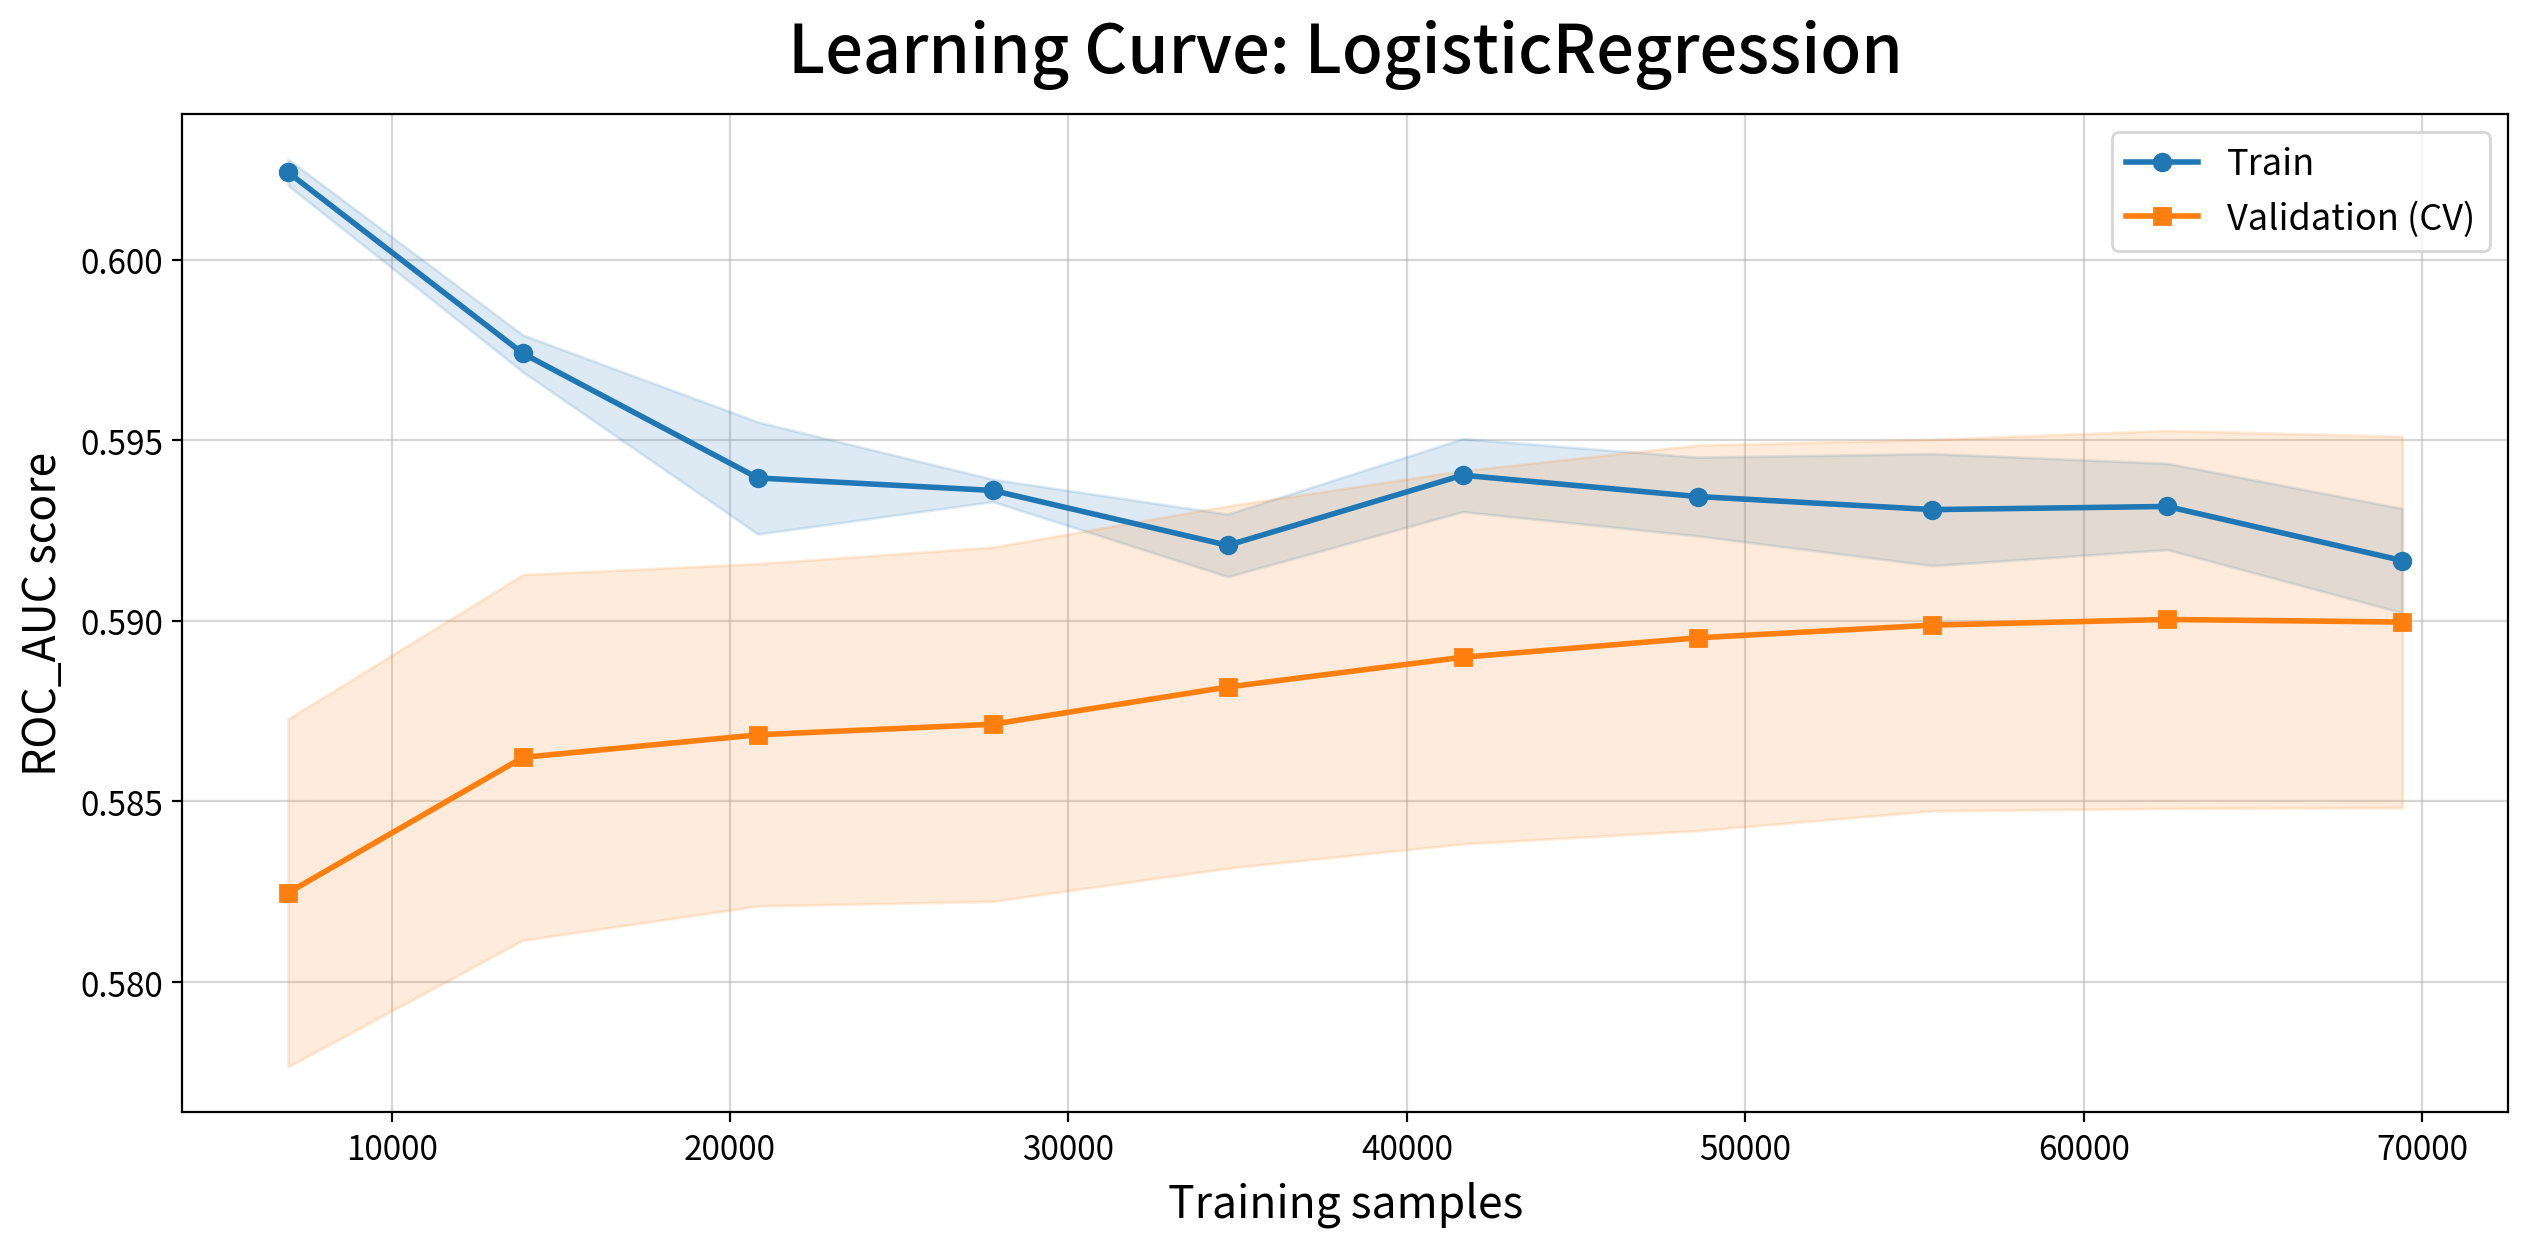


◆ Fit Diagnosis: LogisticRegression  (threshold=15%, 기준=Train↔CV 5-Fold)
   ※ threshold 는 학술 표준이 아닌 경험칙입니다. 임계값보다 학습곡선 추세를 함께 보세요.
   - ROC_AUC  Train=     0.5915  CV=     0.5900 (±0.0051)  Test=     0.5841  Gap%=    0.15%  [과소적합] ⚑
   - F1      Train=     0.0000  CV=     0.0000 (±0.0000)  Test=     0.0000  Gap%=    0.00%  [과소적합] ⚑
   - Accuracy  Train=     0.7950  CV=     0.7950 (±0.0000)  Test=     0.7950  Gap%=    0.00%  [과소적합] ⚑

   ▶ 진단: ⚑ 과소적합 (Underfit · 高편향) — 훈련 성능 자체가 낮음
     · train ROC_AUC=0.5915 (과소적합 기준 < 0.6) · CV ROC_AUC=0.5900


소요 21s
⚠️ F1 · Accuracy 행의 Train/CV/Test 가 모두 같은 값인 것은 helpers 가 임계값 0.5 를 쓰기 때문이다.
   우리 최대 예측확률은 0.4767 라 0.5 를 넘는 행이 거의 없다 (13 #06-3).
   → 판정은 ROC_AUC 행으로 한다. 우리 임계값 θ=0.19 에서의 성능은 #02-2 에서 따로 낸다.


,Train,CV,CV_Std,Test,Gap,Gap%,Overfit
Metric,,,,,,,
ROC_AUC,0.591513,0.589969,0.005143,0.584078,0.001544,0.15,과소적합
F1,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,과소적합
Accuracy,0.794966,0.794954,0.000044,0.794994,0.000012,0.00,과소적합


In [6]:
t = time.time()
OF = my_ml.cls_overfit(LOGIT_SK, X_tr, y_tr, X_te, y_te,
                       metrics=["ROC_AUC", "F1", "Accuracy"],
                       threshold=GAP_PCT, underfit_threshold=UNDERFIT,
                       cv=5, learning_curve=True, verbose=True)
print(f"\n소요 {time.time()-t:.0f}s")
print("⚠️ F1 · Accuracy 행의 Train/CV/Test 가 모두 같은 값인 것은 helpers 가 임계값 0.5 를 쓰기 때문이다.")
print(f"   우리 최대 예측확률은 {p_te_sm.max():.4f} 라 0.5 를 넘는 행이 거의 없다 (13 #06-3).")
print(f"   → 판정은 ROC_AUC 행으로 한다. 우리 임계값 θ={THETA} 에서의 성능은 #02-2 에서 따로 낸다.")
OF

### 2-2. 우리 임계값 θ = 0.19 에서의 CV — helpers 가 대신해 주지 않는 부분

`cls_overfit` 은 임계값 0.5 를 쓰므로 F1 이 0 으로 나온다.
**같은 5-Fold 를 우리 임계값으로 다시 돌려** 폴드별 F1·정밀도·재현율을 낸다.

In [7]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.metrics import precision_score, recall_score

skf = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
rows = []
for k, (i_tr, i_va) in enumerate(skf.split(X_tr, y_tr), 1):
    mdl = clone(LOGIT_SK).fit(X_tr.iloc[i_tr], y_tr.iloc[i_tr])
    pv  = mdl.predict_proba(X_tr.iloc[i_va])[:, 1]
    yv  = y_tr.iloc[i_va]
    yp  = (pv > THETA).astype(int)
    rows.append({"Fold": k, "n": len(yv), "양성률": round(yv.mean(), 4),
                 "ROC_AUC": roc_auc_score(yv, pv), "PR_AUC": average_precision_score(yv, pv),
                 "정밀도": precision_score(yv, yp, zero_division=0),
                 "재현율": recall_score(yv, yp, zero_division=0),
                 "F1": f1_score(yv, yp, zero_division=0)})
CV = DataFrame(rows).set_index("Fold")
FOLDS = list(CV.index)                      # [1..5] — 평균·표준편차 행을 붙이기 전에 잡아둔다
CV.loc["평균"] = CV.loc[FOLDS].mean(numeric_only=True)
CV.loc["표준편차"] = CV.loc[FOLDS].std(numeric_only=True)

te_yp = (p_te_sm > THETA).astype(int)
TE = {"ROC_AUC": roc_auc_score(y_te, p_te_sm), "PR_AUC": average_precision_score(y_te, p_te_sm),
      "정밀도": precision_score(y_te, te_yp, zero_division=0),
      "재현율": recall_score(y_te, te_yp, zero_division=0),
      "F1": f1_score(y_te, te_yp, zero_division=0)}

print(f"5-Fold 각 폴드의 양성률 : {' · '.join(f'{r:.4f}' for r in CV.loc[FOLDS,'양성률'])}  → 층화 유지 확인")
print(f"\nCV 평균 AUC {CV.loc['평균','ROC_AUC']:.4f} (±{CV.loc['표준편차','ROC_AUC']:.4f})"
      f"   ·   test AUC {TE['ROC_AUC']:.4f}")
print(f"CV 평균 F1  {CV.loc['평균','F1']:.4f} (±{CV.loc['표준편차','F1']:.4f})"
      f"   ·   test F1  {TE['F1']:.4f}   (θ={THETA})")
print(f"\n※ 바닥값 — 전부 1로 찍는 모형의 F1 = {2*y_te.mean()/(1+y_te.mean()):.4f}")
CV.round(4)

5-Fold 각 폴드의 양성률 : 0.2050 · 0.2050 · 0.2050 · 0.2050 · 0.2050  → 층화 유지 확인

CV 평균 AUC 0.5896 (±0.0033)   ·   test AUC 0.5841
CV 평균 F1  0.3527 (±0.0024)   ·   test F1  0.3529   (θ=0.19)

※ 바닥값 — 전부 1로 찍는 모형의 F1 = 0.3403


,n,양성률,ROC_AUC,PR_AUC,정밀도,재현율,F1
Fold,,,,,,,
1,17354.0000,0.205,0.5850,0.2622,0.2407,0.6532,0.3518
2,17353.0000,0.205,0.5892,0.2678,0.2398,0.6536,0.3508
3,17353.0000,0.205,0.5942,0.2720,0.2425,0.6728,0.3565
4,17353.0000,0.205,0.5903,0.2661,0.2409,0.6622,0.3533
5,17353.0000,0.205,0.5894,0.2653,0.2383,0.6650,0.3509
평균,17353.2000,0.205,0.5896,0.2667,0.2404,0.6614,0.3527
표준편차,0.4472,0.000,0.0033,0.0036,0.0015,0.0083,0.0024


### 2-3. 판정 — 결정 25번에 대입한다

In [8]:
gap_pct = float(OF.loc["ROC_AUC", "Gap%"]) / 100
gap_auc = float(OF.loc["ROC_AUC", "Train"] - OF.loc["ROC_AUC", "CV"])
tr_auc  = float(OF.loc["ROC_AUC", "Train"])

과대 = (gap_pct >= GAP_PCT) or (gap_auc >= GAP_AUC)
과소 = tr_auc < UNDERFIT

판정 = DataFrame([
    ("과대적합 — Gap%",      f"{gap_pct:.2%}", f"≥ {GAP_PCT:.0%}",   gap_pct >= GAP_PCT),
    ("과대적합 — AUC 절대차", f"{gap_auc:.4f}", f"≥ {GAP_AUC}",       gap_auc >= GAP_AUC),
    ("과소적합 — train AUC", f"{tr_auc:.4f}",  f"< {UNDERFIT}",      과소),
], columns=["기준", "실측", "임계", "해당"])

print("결정 25번 대입 결과")
display(판정)
print(f"→ 과대적합 : {'❌ 해당' if 과대 else '✅ 근거 없음'}")
print(f"→ 과소적합 : {'⚑ 해당' if 과소 else '✅ 해당 없음'}")
print()
if 과소 and not 과대:
    print("판정 : **과소적합(高편향).** 과대적합의 근거는 없다.")
    print("  train 과 CV 가 거의 같다는 것은 모형이 train 을 외우지 못했다는 뜻이다.")
    print("  변수를 줄이거나 규제를 거는 처방은 **방향이 반대**다 — 이 모형은 이미 단순하다.")
    print("  진단 §2 에서 더 복잡한 모형(부스팅)을 시도했고 그 결과는 #03 에 있다.")
print()
print(f"※ CV 표준편차 {CV.loc['표준편차','ROC_AUC']:.4f} · test AUC 의 SE 0.0049 (진단 §1)")
print("  → 이 정도 격차는 표본 오차와 구분되지 않는다. 학습곡선의 추세를 함께 읽는다.")

결정 25번 대입 결과


,기준,실측,임계,해당
0,과대적합 — Gap%,0.15%,≥ 15%,False
1,과대적합 — AUC 절대차,0.0015,≥ 0.01,False
2,과소적합 — train AUC,0.5915,< 0.6,True


→ 과대적합 : ✅ 근거 없음
→ 과소적합 : ⚑ 해당

판정 : **과소적합(高편향).** 과대적합의 근거는 없다.
  train 과 CV 가 거의 같다는 것은 모형이 train 을 외우지 못했다는 뜻이다.
  변수를 줄이거나 규제를 거는 처방은 **방향이 반대**다 — 이 모형은 이미 단순하다.
  진단 §2 에서 더 복잡한 모형(부스팅)을 시도했고 그 결과는 #03 에 있다.

※ CV 표준편차 0.0033 · test AUC 의 SE 0.0049 (진단 §1)
  → 이 정도 격차는 표본 오차와 구분되지 않는다. 학습곡선의 추세를 함께 읽는다.


---

## #03. 트리 계열 비교 (⑦) — **로지스틱이 놓친 구조가 있는가**

계획 보고서 §6 이 약속한 일이다. **성능 경쟁이 아니라 진단이다.**

**같은 조건으로 맞춘다** — 같은 층화 분할 · 같은 28열 설계행렬 · 같은 `RANDOM_STATE`.
트리는 더미·로그·스케일이 필요 없지만, **비교의 공정성을 위해 로지스틱과 같은 입력을 준다.**

⚠️ **하이퍼파라미터를 탐색하지 않는다.** 트리를 튜닝해서 이기게 만들면
"로지스틱이 놓친 구조" 가 아니라 "튜닝의 차이" 를 재게 된다. 상식적인 규제값만 고정으로 준다.

트리 계열은 **6종**을 본다 — sklearn 내장 3종(의사결정나무 · 랜덤포레스트 · HistGB)에
**xgboost · lightgbm · catboost** 를 더한다. `#01` 에서 세 패키지를 설치했으므로
부스팅 계열을 실제 라이브러리로 대표한다. `cls_baseline`(11종)은 SVC 때문에 매우 느려
쓰지 않고, 여기서 필요한 6종만 같은 설계행렬에 직접 적합한다.

> 세 부스터에 **HistGB 와 같은 계열의 규제값**(트리 200그루 · 학습률 0.05 · 깊이 3 ·
> 잎 최소표본 100 · L2 규제 · 행·열 부분표본 0.8)을 고정으로 준다. 탐색이 아니라
> "상식적인 기본값" 이며, sklearn 3종의 규제값과 성격이 같다.

In [9]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# 탐색 금지 — 세 부스터 모두 sklearn HistGB 와 같은 계열의 규제값을 고정으로 준다
#   트리 200그루 · 학습률 0.05 · 깊이 얕게(3) · 잎 최소표본 100 · L2 규제 · 행/열 부분표본 0.8
TREES = {
    "의사결정나무": DecisionTreeClassifier(max_depth=5, min_samples_leaf=200,
                                     random_state=RANDOM_STATE),
    "랜덤포레스트": RandomForestClassifier(n_estimators=300, min_samples_leaf=50,
                                     n_jobs=-1, random_state=RANDOM_STATE),
    "부스팅(HistGB)": HistGradientBoostingClassifier(max_iter=200, learning_rate=0.05,
                                                min_samples_leaf=100, l2_regularization=1.0,
                                                random_state=RANDOM_STATE),
    "부스팅(XGBoost)": XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=3,
                                  min_child_weight=100, reg_lambda=1.0,
                                  subsample=0.8, colsample_bytree=0.8,
                                  random_state=RANDOM_STATE, n_jobs=-1,
                                  eval_metric="logloss"),
    "부스팅(LightGBM)": LGBMClassifier(n_estimators=200, learning_rate=0.05, num_leaves=15,
                                    max_depth=3, min_child_samples=100, reg_lambda=1.0,
                                    subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
                                    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    "부스팅(CatBoost)": CatBoostClassifier(iterations=200, learning_rate=0.05, depth=3,
                                        l2_leaf_reg=3.0, random_seed=RANDOM_STATE,
                                        verbose=0, allow_writing_files=False),
}

FITS = {"로지스틱 A1": LOGIT_SK}
rows = [{"모델": "로지스틱 A1", "train AUC": auc_tr, "test AUC": auc_te,
         "Gap": auc_tr - auc_te, "적합 시간(s)": 0.0}]
for nm, mdl in TREES.items():
    t = time.time(); mdl.fit(X_tr, y_tr); mdl.name_ = nm; FITS[nm] = mdl
    a1 = roc_auc_score(y_tr, mdl.predict_proba(X_tr)[:, 1])
    a2 = roc_auc_score(y_te, mdl.predict_proba(X_te)[:, 1])
    rows.append({"모델": nm, "train AUC": a1, "test AUC": a2,
                 "Gap": a1 - a2, "적합 시간(s)": round(time.time() - t, 1)})
TREE = DataFrame(rows).set_index("모델").round(4)
TREE["ΔAUC (vs 로지스틱)"] = (TREE["test AUC"] - auc_te).round(4)
print(TREE.to_string())
print(f"\n※ test AUC 의 SE 는 0.0049 다 (진단 §1). 0.584 ~ 0.594 구간의 모형들은")
print("  단독 값만으로는 구분되지 않는다. 그래서 #03-2 에서 짝지은 차이의 구간을 구한다.")

               train AUC  test AUC     Gap  적합 시간(s)  ΔAUC (vs 로지스틱)
모델                                                                  
로지스틱 A1           0.5915    0.5841  0.0074       0.0          0.0000
의사결정나무            0.5947    0.5888  0.0059       0.2          0.0047
랜덤포레스트            0.6389    0.5922  0.0466       3.8          0.0081
부스팅(HistGB)       0.6208    0.5964  0.0245       3.2          0.0123
부스팅(XGBoost)      0.6044    0.5954  0.0090       0.9          0.0113
부스팅(LightGBM)     0.6075    0.5969  0.0106       0.6          0.0128
부스팅(CatBoost)     0.5993    0.5911  0.0082       1.6          0.0070

※ test AUC 의 SE 는 0.0049 다 (진단 §1). 0.584 ~ 0.594 구간의 모형들은
  단독 값만으로는 구분되지 않는다. 그래서 #03-2 에서 짝지은 차이의 구간을 구한다.


### 3-1. helpers 비교표 — `primary='ROC_AUC'` 로 바꿔서 쓴다

⚠️ `cls_compare_models` 의 기본 주 지표는 `'F1'` 인데, helpers 의 F1 은 **임계값 0.5 고정**이라
이 데이터에서는 **모든 모형이 0** 이 된다. 순위가 매겨지지 않으므로 `'ROC_AUC'` 로 바꾼다.

In [10]:
CMP = my_ml.cls_compare_models(FITS, X_te, y_te, primary="ROC_AUC",
                               aux=["PR_AUC", "LogLoss"], verbose=False)
print("⚠️ Precision · Recall · F1 · MCC 가 0 이거나 극단값인 것은 임계값 0.5 때문이다 (helpers 주의 1번).")
print("   0.5 를 넘는 행이 모형별로 0~1건뿐이라, 1건을 맞히면 Precision 이 1.0 으로 튄다.")
print("   → **이 열들로 모형을 비교하면 안 된다.** 순위는 ROC_AUC · PR_AUC 로만 읽는다.")
print(f"   우리 임계값 θ={THETA} 에서의 성능은 #03-3 에 있다.\n")
CMP.round(4)

⚠️ Precision · Recall · F1 · MCC 가 0 이거나 극단값인 것은 임계값 0.5 때문이다 (helpers 주의 1번).
   0.5 를 넘는 행이 모형별로 0~1건뿐이라, 1건을 맞히면 Precision 이 1.0 으로 튄다.
   → **이 열들로 모형을 비교하면 안 된다.** 순위는 ROC_AUC · PR_AUC 로만 읽는다.
   우리 임계값 θ=0.19 에서의 성능은 #03-3 에 있다.



,Rank,Group,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,LogLoss,MCC,ROC_AUC_Gap
name,,,,,,,,,,,,
부스팅(LightGBM),1,Contender,LGBMClassifier,0.7949,0.0000,0.0000,0.0000,0.5969,0.2722,0.4976,-0.0034,-0.000
부스팅(HistGB),2,Contender,HistGradientBoostingClassifier,0.7950,0.6667,0.0004,0.0009,0.5964,0.2702,0.4979,0.0134,0.001
부스팅(XGBoost),3,Contender,XGBClassifier,0.7950,0.0000,0.0000,0.0000,0.5954,0.2711,0.4978,0.0000,0.002
랜덤포레스트,4,Contender,RandomForestClassifier,0.7950,0.0000,0.0000,0.0000,0.5922,0.2684,0.4986,0.0000,0.008
부스팅(CatBoost),5,Contender,CatBoostClassifier,0.7950,0.0000,0.0000,0.0000,0.5911,0.2715,0.4986,0.0000,0.010
의사결정나무,6,Contender,DecisionTreeClassifier,0.7950,0.0000,0.0000,0.0000,0.5888,0.2624,0.4988,0.0000,0.014
로지스틱 A1,7,Contender,LogisticRegression,0.7950,0.0000,0.0000,0.0000,0.5841,0.2609,0.5005,0.0000,0.021


### 3-2. 차이의 불확실성 — 짝지은 ΔAUC 의 95% 구간

같은 test 표본에서 두 모형을 함께 평가하므로 **행 단위로 짝지어** 재표집한다.
「교재 미기재」인 방법이므로 무엇을 했는지 밝힌다 —
*test 21,692행을 복원추출로 1,000번 다시 뽑아, 매번 두 모형의 AUC 차를 계산했다.*

**유의성과 크기를 분리해 읽는다.** 표본이 크면 0.01 짜리 차이도 구간이 0 을 비켜가지만,
그것이 **판정 기준 0.02 를 넘긴다는 뜻은 아니다.**

In [11]:
PROBA = {nm: (mdl.predict_proba(X_te)[:, 1]) for nm, mdl in FITS.items()}
rng = np.random.RandomState(RANDOM_STATE)
yv = y_te.values
BOOT_IDX = [rng.randint(0, len(yv), len(yv)) for _ in range(N_BOOT)]

rows = []
for nm in TREES:
    ds = np.array([roc_auc_score(yv[i], PROBA[nm][i]) - roc_auc_score(yv[i], PROBA["로지스틱 A1"][i])
                   for i in BOOT_IDX])
    lo, hi = np.percentile(ds, [2.5, 97.5])
    delta = float(roc_auc_score(yv, PROBA[nm]) - auc_te)
    rows.append({"트리": nm, "ΔAUC": round(delta, 4),
                 "95% 하한": round(float(lo), 4), "95% 상한": round(float(hi), 4),
                 "0 포함": bool(lo < 0 < hi),
                 "기준 0.02 초과": bool(abs(delta) >= TREE_SMALL)})
DELTA = DataFrame(rows).set_index("트리")
print(f"재표집 {N_BOOT}회 · 짝지은 차이")
DELTA

재표집 1000회 · 짝지은 차이


,ΔAUC,95% 하한,95% 상한,0 포함,기준 0.02 초과
트리,,,,,
의사결정나무,0.0047,-0.0007,0.0103,True,False
랜덤포레스트,0.0081,0.0034,0.0129,False,False
부스팅(HistGB),0.0123,0.0075,0.0172,False,False
부스팅(XGBoost),0.0114,0.0073,0.0153,False,False
부스팅(LightGBM),0.0128,0.0085,0.0171,False,False
부스팅(CatBoost),0.0071,0.0036,0.0105,False,False


### 3-3. 우리 임계값 θ = 0.19 에서의 성능 — 모형 간 같은 자로 잰다

⚠️ 각 모형마다 F1 최적 임계값이 다르지만, **여기서는 임계값을 고정한다.**
임계값이 다르면 재현율·정밀도를 나란히 놓을 수 없기 때문이다 (사과와 오렌지 비교가 된다).

In [12]:
def 리프트(p, pct):
    o = np.argsort(-p)
    k = int(len(p) * pct)
    return yv[o][:k].mean() / yv.mean()

rows = []
for nm, p in PROBA.items():
    yp = (p > THETA).astype(int)
    rows.append({"모델": nm, "ROC_AUC": roc_auc_score(yv, p), "PR_AUC": average_precision_score(yv, p),
                 f"정밀도(θ={THETA})": precision_score(yv, yp, zero_division=0),
                 f"재현율(θ={THETA})": recall_score(yv, yp, zero_division=0),
                 f"F1(θ={THETA})": f1_score(yv, yp, zero_division=0),
                 "상위5% 리프트": 리프트(p, 0.05), "상위10% 리프트": 리프트(p, 0.10)})
SAME = DataFrame(rows).set_index("모델").round(4)
바닥F1 = 2 * yv.mean() / (1 + yv.mean())
print(f"바닥값 — 전부 1로 찍기 : F1 {바닥F1:.4f} · 정밀도 {yv.mean():.4f} · 재현율 1.0000 · 리프트 1.000배")
print(f"PR_AUC 의 바닥값(기저율) : {yv.mean():.4f}")
SAME

바닥값 — 전부 1로 찍기 : F1 0.3403 · 정밀도 0.2050 · 재현율 1.0000 · 리프트 1.000배
PR_AUC 의 바닥값(기저율) : 0.2050


,ROC_AUC,PR_AUC,정밀도(θ=0.19),재현율(θ=0.19),F1(θ=0.19),상위5% 리프트,상위10% 리프트
모델,,,,,,,
로지스틱 A1,0.5841,0.2609,0.2399,0.6672,0.3529,1.5345,1.4573
의사결정나무,0.5888,0.2624,0.2474,0.6000,0.3504,1.6560,1.5967
랜덤포레스트,0.5922,0.2684,0.2465,0.6296,0.3543,1.6830,1.5832
부스팅(HistGB),0.5964,0.2702,0.2461,0.6305,0.3540,1.6830,1.5810
부스팅(XGBoost),0.5954,0.2711,0.2471,0.6155,0.3527,1.6875,1.5990
부스팅(LightGBM),0.5969,0.2722,0.2464,0.6265,0.3537,1.6785,1.6125
부스팅(CatBoost),0.5911,0.2715,0.2419,0.6368,0.3506,1.6785,1.5922


### 3-4. 변수 중요도 대조 — 트리와 로지스틱은 다른 것을 본다

⚠️ `feature_importance` 는 트리 기준(MDI)이라 **분기 기회가 많은 연속형을 과대평가**한다.
`price` 는 고유값 1,708개라 더미 변수보다 구조적으로 유리하다.
**어느 한쪽을 정답으로 삼지 않고, 두 순위가 어긋나는 지점을 해석한다.**

In [13]:
FI = my_ml.feature_importance(FITS["랜덤포레스트"], top_n=10, plot=False, verbose=False)

BSTD = VAR_A.set_index("독립변수") if "독립변수" in VAR_A.columns else VAR_A
BSTD = BSTD.assign(절대βstd=BSTD["βstd"].abs()).sort_values("절대βstd", ascending=False)

대조 = DataFrame({
    "트리 중요도 순위": {c: i + 1 for i, c in enumerate(FI.index[:10])},
    "βstd 순위":       {c: i + 1 for i, c in enumerate(BSTD.index[:10])},
})
대조 = 대조.assign(중요도=FI["Importance"].reindex(대조.index).round(4),
                 βstd=BSTD["βstd"].reindex(대조.index).round(4))
print("상위 10 안에 든 항만 표시 — 한쪽에만 있으면 NaN")
display(대조.sort_values("βstd 순위"))
print("※ price 가 트리에서 1위(중요도 42.5% 규모)인 것은 연속형 편향의 영향이 크다.")
print("  로지스틱 βstd 1위는 cart_product_view_cnt_c 다. 이 어긋남을 결과 보고서에 적는다.")

상위 10 안에 든 항만 표시 — 한쪽에만 있으면 NaN


,트리 중요도 순위,βstd 순위,중요도,βstd
cart_product_view_cnt_c,2.0,1.0,0.1135,0.2797
price,1.0,2.0,0.4253,0.1521
cart_timeband_오후,7.0,3.0,0.0234,0.1102
prior_view_cnt_c,4.0,4.0,0.0486,-0.1091
cart_timeband_오전,NaN,5.0,0.0156,0.0782
prior_view_cnt_c2,5.0,6.0,0.0405,0.0743
brand_grp_italwax,6.0,7.0,0.0244,0.0671
brand_grp_bpw.style,NaN,8.0,0.0161,-0.0592
cart_timeband_저녁,9.0,9.0,0.0175,0.0538
brand_grp_masura,NaN,10.0,0.0078,-0.0408


※ price 가 트리에서 1위(중요도 42.5% 규모)인 것은 연속형 편향의 영향이 크다.
  로지스틱 βstd 1위는 cart_product_view_cnt_c 다. 이 어긋남을 결과 보고서에 적는다.


---

## #04. 판정 — 사전 규칙에 대입한다 〈검수하는 사람〉

`#02`·`#03` 의 결과를 **결정 25·26·27번의 문장에 그대로 대입**한다. 여기서 규칙을 만들지 않는다.

In [14]:
best = TREE.drop(index="로지스틱 A1")["test AUC"].idxmax()
d = float(TREE.loc[best, "ΔAUC (vs 로지스틱)"])
lo, hi = float(DELTA.loc[best, "95% 하한"]), float(DELTA.loc[best, "95% 상한"])

if abs(d) < TREE_SMALL:
    구간, 할일 = "0.02 미만 — 선형으로 충분", "로지스틱 확정. 트리는 결과 보고서에 한 줄로 남긴다"
elif abs(d) < TREE_BIG:
    구간, 할일 = "0.02 ~ 0.05 — 비선형 구조가 조금", "어느 변수인지 보고 상호작용·구간화를 검토한다"
else:
    구간, 할일 = "0.05 초과 — 놓친 구조가 크다", "변수 설계를 재검토하고 결과에 명시한다"

print("결정 26번 판정 규칙 (계획 보고서 §6, 사전 확정)")
print("  ΔAUC 0.02 미만 → 선형으로 충분 / 0.02~0.05 → 비선형 조금 / 0.05 초과 → 놓친 구조 큼")
print()
print(f"결과 → 최고 트리 = {best}   ΔAUC = {d:+.4f}   95% CI [{lo:+.4f}, {hi:+.4f}]")
print(f"       구간 판정 : {구간}")
print(f"       할 일     : {할일}")
print()
if not DELTA.loc[best, "0 포함"] and abs(d) < TREE_SMALL:
    print("⚠️ 구간이 0 을 비켜가므로 차이는 '우연이 아니다'. 그러나 크기가 판정 기준 0.02 에 못 미친다.")
    print("   → **유의하지만 작다.** 두 문장을 함께 써야 정확하다. 하나만 쓰면 어느 쪽으로도 오독된다.")
print()
print("결정 27번 — 최종 해석 모형은 로지스틱 A1 이다. 성능이 좋다고 트리로 바꾸지 않는다.")
print(f"  계획 보고서 §1 의 질문이 '어떤 조건이 기여하는가' 이므로 계수·오즈비로 답해야 한다.")
print()
print("🔴 이 선택의 대가를 숫자로 적어 둔다 — 감추면 '몰라서 안 했다'로 읽힌다.")
print(f"     AUC        {auc_te:.4f} → {TREE.loc[best,'test AUC']:.4f}   ({d:+.4f})")
print(f"     상위5% 리프트 {SAME.loc['로지스틱 A1','상위5% 리프트']:.3f} → {SAME.loc[best,'상위5% 리프트']:.3f}배"
      f"   ({SAME.loc[best,'상위5% 리프트']-SAME.loc['로지스틱 A1','상위5% 리프트']:+.3f})")
print(f"     PR-AUC     {SAME.loc['로지스틱 A1','PR_AUC']:.4f} → {SAME.loc[best,'PR_AUC']:.4f}"
      f"   ({SAME.loc[best,'PR_AUC']-SAME.loc['로지스틱 A1','PR_AUC']:+.4f})")
print("  → 예측만이 목적이라면 부스팅이 낫다. 우리는 **계수를 읽어야 하므로** 로지스틱을 택했다.")
print("     이 트레이드오프를 결과 보고서 Ⅳ-2 와 Ⅵ-3 에 그대로 옮긴다.")

결정 26번 판정 규칙 (계획 보고서 §6, 사전 확정)
  ΔAUC 0.02 미만 → 선형으로 충분 / 0.02~0.05 → 비선형 조금 / 0.05 초과 → 놓친 구조 큼

결과 → 최고 트리 = 부스팅(LightGBM)   ΔAUC = +0.0128   95% CI [+0.0085, +0.0171]
       구간 판정 : 0.02 미만 — 선형으로 충분
       할 일     : 로지스틱 확정. 트리는 결과 보고서에 한 줄로 남긴다

⚠️ 구간이 0 을 비켜가므로 차이는 '우연이 아니다'. 그러나 크기가 판정 기준 0.02 에 못 미친다.
   → **유의하지만 작다.** 두 문장을 함께 써야 정확하다. 하나만 쓰면 어느 쪽으로도 오독된다.

결정 27번 — 최종 해석 모형은 로지스틱 A1 이다. 성능이 좋다고 트리로 바꾸지 않는다.
  계획 보고서 §1 의 질문이 '어떤 조건이 기여하는가' 이므로 계수·오즈비로 답해야 한다.

🔴 이 선택의 대가를 숫자로 적어 둔다 — 감추면 '몰라서 안 했다'로 읽힌다.
     AUC        0.5841 → 0.5969   (+0.0128)
     상위5% 리프트 1.534 → 1.679배   (+0.144)
     PR-AUC     0.2609 → 0.2722   (+0.0113)
  → 예측만이 목적이라면 부스팅이 낫다. 우리는 **계수를 읽어야 하므로** 로지스틱을 택했다.
     이 트레이드오프를 결과 보고서 Ⅳ-2 와 Ⅵ-3 에 그대로 옮긴다.


---

## #05. βstd 순위와 오즈비 해석 (⑧) — 여기서부터 보고서 Ⅴ 다

### 5-1. 영향력 순위 — **βstd 로 다시 정렬한다**

⚠️ `report_variables` 는 **|B| 내림차순**으로 돌려준다(교재정리 §9-③).
B 는 변수의 단위에 좌우되므로 **영향력 비교에는 βstd 를 써야 한다.**

βstd = B × SD(x) — *"독립변수가 1 표준편차 늘 때 log(오즈)가 얼마나 변하는가"*.
로지스틱은 종속변수가 0/1 이라 **독립변수만 표준화한다.**

In [15]:
TOP = BSTD.head(12)[["B", "βstd", "오즈비(OR)", "OR 95 하한", "OR 95 상한", "유의확률", "VIF"]]
유의 = BSTD[BSTD["유의확률"] < ALPHA]

print(f"전체 {len(BSTD)}항 중 유의(α={ALPHA}) {len(유의)}항")
print(f"|βstd| 0.20 이상 {int((유의['절대βstd']>=0.20).sum())}항 · "
      f"0.10~0.20 {int(((유의['절대βstd']>=0.10)&(유의['절대βstd']<0.20)).sum())}항 · "
      f"0.05~0.10 {int(((유의['절대βstd']>=0.05)&(유의['절대βstd']<0.10)).sum())}항 · "
      f"0.05 미만 {int((유의['절대βstd']<0.05).sum())}항")
print()
print(f"⚠️ n = {int(A1.nobs):,} 에서는 이론상 |βstd| 가 {1.96/np.sqrt(A1.nobs):.4f} 만 넘어도 유의해진다.")
print(f"   실제 유의한 항의 |βstd| 최솟값은 {유의['절대βstd'].min():.4f}, 중앙값은 {유의['절대βstd'].median():.4f} 다.")
print("   → **'유의하다'가 '중요하다'를 뜻하지 않는다.** 실질적으로 읽을 항은 상위 4개다.")
TOP.round(4)

전체 28항 중 유의(α=0.05) 19항
|βstd| 0.20 이상 1항 · 0.10~0.20 3항 · 0.05~0.10 5항 · 0.05 미만 10항

⚠️ n = 86,766 에서는 이론상 |βstd| 가 0.0067 만 넘어도 유의해진다.
   실제 유의한 항의 |βstd| 최솟값은 0.0186, 중앙값은 0.0408 다.
   → **'유의하다'가 '중요하다'를 뜻하지 않는다.** 실질적으로 읽을 항은 상위 4개다.


,B,βstd,오즈비(OR),OR 95 하한,OR 95 상한,유의확률,VIF
독립변수,,,,,,,
cart_product_view_cnt_c,0.7203,0.2797,2.0550,1.9004,2.2221,0.0000,3.1807
price,0.1347,0.1521,1.1442,1.1260,1.1628,0.0000,1.1928
cart_timeband_오후,0.2296,0.1102,1.2581,1.1775,1.3443,0.0000,3.3753
prior_view_cnt_c,-0.1725,-0.1091,0.8416,0.8010,0.8842,0.0000,3.0973
cart_timeband_오전,0.1889,0.0782,1.2079,1.1263,1.2954,0.0000,2.8175
prior_view_cnt_c2,0.1083,0.0743,1.1143,1.0775,1.1524,0.0000,1.9906
brand_grp_italwax,0.4316,0.0671,1.5398,1.3701,1.7305,0.0000,1.3713
brand_grp_bpw.style,-0.4309,-0.0592,0.6499,0.5507,0.7670,0.0000,1.3012
cart_timeband_저녁,0.1138,0.0538,1.1206,1.0479,1.1983,0.0009,3.3056


### 5-2. 명목형은 **무엇 대비**인가 — 기준 범주를 반드시 병기한다

오즈비 문장은 기준을 밝히지 않으면 성립하지 않는다. `12j` 가 그 답을 갖고 있다.

In [16]:
print("기준 범주 (12j · 결정 23번)")
for i, r in REFTAB.iterrows():
    if i == "category_grp":
        continue          # 모형 B 전용. A1 에는 없다
    print(f"  {i:16s} → 기준 '{r['우리가 지정한 기준']}' (train 비중 {r['지정 비중(%)']:.2f}%)"
          f"   · helpers 기본값이었다면 '{r['helpers 기본 기준']}'")
print()
print("→ A1 의 명목형 오즈비는 전부 위 기준 대비다. 결과 보고서 Ⅴ 표에 이 줄을 함께 싣는다.")
REFTAB.drop(index="category_grp", errors="ignore")

기준 범주 (12j · 결정 23번)
  brand_grp        → 기준 'runail' (train 비중 6.24%)   · helpers 기본값이었다면 'bpw.style'
  cart_timeband    → 기준 '심야' (train 비중 8.45%)   · helpers 기본값이었다면 '심야'
  cart_weekday     → 기준 '월' (train 비중 14.36%)   · helpers 기본값이었다면 '금'

→ A1 의 명목형 오즈비는 전부 위 기준 대비다. 결과 보고서 Ⅴ 표에 이 줄을 함께 싣는다.


,종수,helpers 기본 기준,기본 비중(%),우리가 지정한 기준,지정 비중(%),교체,모형
변수,,,,,,,
brand_grp,15,bpw.style,1.92,runail,6.24,True,A·B
cart_timeband,4,심야,8.45,심야,8.45,False,A·B
cart_weekday,7,금,16.82,월,14.36,True,A·B


### 5-3. 제곱항이 든 변수는 **곡선으로 읽는다** — 단일 오즈비로 읽지 않는다

`prior_view_cnt` 와 `cart_product_view_cnt` 는 `_c`(1차) 와 `_c2`(2차) 를 함께 봐야 한다.
꼭짓점 x\* = −B₁ / (2·B₂) 을 구하고, **그 지점이 실제 데이터 범위 안에 있는지** 확인한다.
범위 밖이면 곡선이 아니라 단조로 읽어야 한다.

In [17]:
import json
RECIPE = json.load(open(OUT + r"\13c_recipe.json", encoding="utf-8"))
m03 = read_csv(OUT + r"\03_master.csv", encoding="utf-8-sig",
               usecols=["prior_view_cnt", "cart_product_view_cnt"])

rows = []
for var, rule in RECIPE.items():
    B1 = float(BSTD.loc[var + "_c", "B"]); B2 = float(BSTD.loc[var + "_c2", "B"])
    c  = float(rule["center"])
    xc = -B1 / (2 * B2)
    raw = float(np.expm1(xc + c))                 # log1p 중심화 척도 → 원단위
    beyond = float((m03[var] > raw).mean())
    rows.append({"변수": var, "B₁(_c)": round(B1, 4), "B₂(_c2)": round(B2, 4),
                 "꼭짓점(원단위)": round(raw, 2), "그 너머 표본": f"{beyond:.2%}",
                 "볼록 방향": "아래(U자)" if B2 > 0 else "위(∩자)",
                 "실제 형태": ("U자 — 반등 구간이 실재" if B2 > 0 and beyond > 0.01 else
                             "단조 — 꼭짓점이 데이터 밖" if beyond < 0.01 else
                             "∩자 — 감소 구간이 실재")})
CURVE = DataFrame(rows).set_index("변수")
display(CURVE)

print("대표 지점에서의 예측확률 — 다른 변수는 전부 train 평균에 고정한다")
# ⚠️ my_logit.predict 는 add_constant 기본값(has_constant='skip')을 쓴다.
#    행이 적으면 열이 상수로 보여 상수항이 붙지 않으므로, 여기서는 직접 'add' 로 붙인다.
base_row = X_tr.mean().to_frame().T
PTS = [0, 1, 2, 3, 5, 10]
곡선표 = {}
for var in RECIPE:
    c = float(RECIPE[var]["center"])
    rows_ = []
    for v in PTS:
        r = base_row.copy()
        xc = np.log1p(v) - c
        r[var + "_c"], r[var + "_c2"] = xc, xc ** 2
        rows_.append(r)
    D_ = concat(rows_, ignore_index=True)[X_tr.columns]
    probs = A1.predict(sm.add_constant(D_, has_constant="add")).values
    곡선표[var] = [round(float(p), 4) for p in probs]
    print(f"  {var:24s} " + " · ".join(f"{v}회 {p:.3f}" for v, p in zip(PTS, probs)))
곡선표 = DataFrame(곡선표, index=[f"{v}회" for v in PTS]).T
print(f"\n(참고) train 평균 전환율 {y_tr.mean():.3f}")
print("※ 다른 변수를 평균에 고정한 '조건부' 확률이다. 실제 집단 평균과 같지 않다.")

,B₁(_c),B₂(_c2),꼭짓점(원단위),그 너머 표본,볼록 방향,실제 형태
변수,,,,,,
prior_view_cnt,-0.1725,0.1083,2.94,13.79%,아래(U자),U자 — 반등 구간이 실재
cart_product_view_cnt,0.7203,-0.1997,7.15,0.00%,위(∩자),단조 — 꼭짓점이 데이터 밖


대표 지점에서의 예측확률 — 다른 변수는 전부 train 평균에 고정한다
  prior_view_cnt           0회 0.215 · 1회 0.190 · 2회 0.184 · 3회 0.183 · 5회 0.186 · 10회 0.200
  cart_product_view_cnt    0회 0.170 · 1회 0.250 · 2회 0.288 · 3회 0.308 · 5회 0.326 · 10회 0.326

(참고) train 평균 전환율 0.205
※ 다른 변수를 평균에 고정한 '조건부' 확률이다. 실제 집단 평균과 같지 않다.


### 5-3-1. 🔴 곡선을 **단변량과 나란히** 놓는다 — 여기가 오독의 자리다

`#05-3` 의 조건부 확률만 보면 `prior_view_cnt` 는 **0회일 때가 가장 높다.**
그런데 실제 집단의 전환율은 **0회일 때가 가장 낮다.** 방향이 정반대다.

두 수치가 어긋나는 것은 오류가 아니라 **억제 효과(suppression)** 다.
`cart_product_view_cnt` ⊆ `prior_view_cnt` 라서(포함관계 100%, Spearman 0.688),
모형 안의 `prior_view_cnt` 계수는 **"그 상품 조회수를 고정했을 때 남는 다른 상품 조회"** 의 효과다.

**이 표를 그대로 보고서에 싣고, 아래 문장을 함께 쓴다.**

In [18]:
BIN = cut(m03["prior_view_cnt"], [-0.5, 0.5, 1.5, 2.5, 3.5, 5.5, 10.5, np.inf],
          labels=["0", "1", "2", "3", "4-5", "6-10", "11+"])
y_all = read_csv(OUT + r"\03_master.csv", encoding="utf-8-sig", usecols=["purchase_7d"])["purchase_7d"]
UNI = y_all.groupby(BIN, observed=True).agg(["size", "mean"])
UNI.columns = ["인원", "실제 전환율"]
UNI["실제 전환율"] = (UNI["실제 전환율"] * 100).round(2)

# PTS = [0,1,2,3,5,10] 이므로 5회는 '4-5' 구간, 10회는 '6-10' 구간에 속한다
비교 = DataFrame({
    "실제 전환율(%)": UNI["실제 전환율"].reindex(["0", "1", "2", "3", "4-5", "6-10"]).values,
    "모형 조건부 확률(%)": [round(v * 100, 2) for v in 곡선표.loc["prior_view_cnt"].values],
}, index=["0회", "1회", "2회", "3회", "5회(4-5구간)", "10회(6-10구간)"])
비교["방향"] = ["—"] + ["↑" if 비교["실제 전환율(%)"].iloc[i] > 비교["실제 전환율(%)"].iloc[i-1] else "↓"
                     for i in range(1, len(비교))]
display(비교)

print("→ 실제 전환율은 조회가 늘수록 **올라가고**, 모형 조건부 확률은 **내려간다.**")
print("  모순이 아니라 억제 효과다 — 모형 안의 계수는 '그 상품 조회를 고정한 뒤의 나머지 조회' 효과다.")
print()
print("✅ 쓸 수 있는 문장")
print("   '담기 전 조회가 많을수록 전환율은 높아진다(0회 18.5% → 11회 이상 25.7%).")
print("    다만 그 효과의 대부분은 담은 그 상품을 몇 번 봤는가에서 오며,")
print("    그것을 고정하면 나머지 조회는 오히려 음의 방향으로 남는다.'")
print()
print("❌ 쓰면 안 되는 문장")
print("   '많이 둘러본 사람이 아니라 그 상품을 여러 번 본 사람이 산다'")
print("   → 억제 효과를 행동 이론으로 번역한 것. 단변량 방향과 정면으로 어긋난다.")
print()
c5 = 곡선표.loc["cart_product_view_cnt"]
print(f"※ cart_product_view_cnt 는 0회 {c5.iloc[0]:.3f} → 3회 {c5.iloc[3]:.3f} → 10회 {c5.iloc[-1]:.3f} 로")
print(f"  단조 증가하되 5회 부근에서 **포화**한다. '체감 증가'로 쓰고 '∩자'로 쓰지 않는다.")

,실제 전환율(%),모형 조건부 확률(%),방향
0회,18.54,21.52,—
1회,21.67,19.03,↑
2회,22.66,18.40,↑
3회,21.85,18.28,↓
5회(4-5구간),22.31,18.56,↑
10회(6-10구간),22.99,20.04,↑


→ 실제 전환율은 조회가 늘수록 **올라가고**, 모형 조건부 확률은 **내려간다.**
  모순이 아니라 억제 효과다 — 모형 안의 계수는 '그 상품 조회를 고정한 뒤의 나머지 조회' 효과다.

✅ 쓸 수 있는 문장
   '담기 전 조회가 많을수록 전환율은 높아진다(0회 18.5% → 11회 이상 25.7%).
    다만 그 효과의 대부분은 담은 그 상품을 몇 번 봤는가에서 오며,
    그것을 고정하면 나머지 조회는 오히려 음의 방향으로 남는다.'

❌ 쓰면 안 되는 문장
   '많이 둘러본 사람이 아니라 그 상품을 여러 번 본 사람이 산다'
   → 억제 효과를 행동 이론으로 번역한 것. 단변량 방향과 정면으로 어긋난다.

※ cart_product_view_cnt 는 0회 0.170 → 3회 0.308 → 10회 0.327 로
  단조 증가하되 5회 부근에서 **포화**한다. '체감 증가'로 쓰고 '∩자'로 쓰지 않는다.


### 5-4. 오즈비 해석 문장 — 초안을 받아 사람이 고친다

⚠️ 이 함수는 **모든 항을 같은 틀로** 문장화한다. 제곱항이 든 변수까지
*"1 증가할 때 오즈가 ○% 증가"* 로 써 주므로 **그 대목은 반드시 손으로 고친다.**
`#05-3` 의 곡선 서술로 바꿔 쓴다.

In [19]:
TXT = my_logit.report_variables_text(A1, data=TRAIN, alpha=ALPHA)
display(Markdown(TXT))

- **price**의 회귀계수는 **B = 0.1347**, 오즈비는 **OR = 1.1442**로 나타났으며, 이는 **purchase_7d**에 유의한 요인임을 의미한다. (**z = 16.44**, **p < .001**) 즉, **price**가 1 증가할 때 purchase_7d가 1(사건 발생)이 될 오즈는 평균적으로 약 **14.4% 증가**하는 것으로 해석된다.
- **brand_grp_bpw.style**의 회귀계수는 **B = -0.4309**, 오즈비는 **OR = 0.6499**로 나타났으며, 이는 **purchase_7d**에 유의한 요인임을 의미한다. (**z = -5.1**, **p < .001**) 즉, **brand_grp_bpw.style**에 해당하는 경우(기준 범주 대비) purchase_7d가 1(사건 발생)이 될 오즈는 평균적으로 약 **35.0% 감소**하는 것으로 해석된다.
- **brand_grp_cnd**의 회귀계수는 **B = 0.1398**, 오즈비는 **OR = 1.15**로 나타났으며, 이는 **purchase_7d**에 유의한 요인임을 의미한다. (**z = 2.02**, **p = .044**) 즉, **brand_grp_cnd**에 해당하는 경우(기준 범주 대비) purchase_7d가 1(사건 발생)이 될 오즈는 평균적으로 약 **15.0% 증가**하는 것으로 해석된다.
- **brand_grp_concept**의 회귀계수는 **B = 0.1595**, 오즈비는 **OR = 1.1729**로 나타났으며, 이는 **purchase_7d**에 유의한 요인임을 의미한다. (**z = 2.46**, **p = .014**) 즉, **brand_grp_concept**에 해당하는 경우(기준 범주 대비) purchase_7d가 1(사건 발생)이 될 오즈는 평균적으로 약 **17.3% 증가**하는 것으로 해석된다.
- **brand_grp_estel**의 회귀계수는 **B = 0.1362**, 오즈비는 **OR = 1.146**로 나타났으며, 이는 **purchase_7d**에 유의한 요인임을 의미한다. (**z = 2.32**, **p = .020**) 즉, **brand_grp_estel**에 해당하는 경우(기준 범주 대비) purchase_7d가 1(사건 발생)이 될 오즈는 평균적으로 약 **14.6% 증가**하는 것으로 해석된다.
- **brand_grp_grattol**의 회귀계수는 **B = -0.0097**, 오즈비는 **OR = 0.9903**로 나타났으며, 이는 **purchase_7d**에 유의하지 않은 요인임을 의미한다. (**z = -0.18**, **p = .856**) 즉, **brand_grp_grattol**에 해당하는 경우(기준 범주 대비) purchase_7d가 1(사건 발생)이 될 오즈는 평균적으로 약 **1.0% 감소**하는 것으로 해석된다.
- **brand_grp_ingarden**의 회귀계수는 **B = -0.1929**, 오즈비는 **OR = 0.8245**로 나타났으며, 이는 **purchase_7d**에 유의한 요인임을 의미한다. (**z = -2.46**, **p = .014**) 즉, **brand_grp_ingarden**에 해당하는 경우(기준 범주 대비) purchase_7d가 1(사건 발생)이 될 오즈는 평균적으로 약 **17.5% 감소**하는 것으로 해석된다.
- **brand_grp_irisk**의 회귀계수는 **B = -0.1792**, 오즈비는 **OR = 0.8359**로 나타났으며, 이는 **purchase_7d**에 유의한 요인임을 의미한다. (**z = -3.32**, **p < .001**) 즉, **brand_grp_irisk**에 해당하는 경우(기준 범주 대비) purchase_7d가 1(사건 발생)이 될 오즈는 평균적으로 약 **16.4% 감소**하는 것으로 해석된다.
- **brand_grp_italwax**의 회귀계수는 **B = 0.4316**, 오즈비는 **OR = 1.5398**로 나타났으며, 이는 **purchase_7d**에 유의한 요인임을 의미한다. (**z = 7.25**, **p < .001**) 즉, **brand_grp_italwax**에 해당하는 경우(기준 범주 대비) purchase_7d가 1(사건 발생)이 될 오즈는 평균적으로 약 **54.0% 증가**하는 것으로 해석된다.
- **brand_grp_jessnail**의 회귀계수는 **B = -0.171**, 오즈비는 **OR = 0.8428**로 나타났으며, 이는 **purchase_7d**에 유의한 요인임을 의미한다. (**z = -2.19**, **p = .029**) 즉, **brand_grp_jessnail**에 해당하는 경우(기준 범주 대비) purchase_7d가 1(사건 발생)이 될 오즈는 평균적으로 약 **15.7% 감소**하는 것으로 해석된다.
- **brand_grp_kapous**의 회귀계수는 **B = 0.0808**, 오즈비는 **OR = 1.0841**로 나타났으며, 이는 **purchase_7d**에 유의하지 않은 요인임을 의미한다. (**z = 1.29**, **p = .197**) 즉, **brand_grp_kapous**에 해당하는 경우(기준 범주 대비) purchase_7d가 1(사건 발생)이 될 오즈는 평균적으로 약 **8.4% 증가**하는 것으로 해석된다.
- **brand_grp_masura**의 회귀계수는 **B = -0.2455**, 오즈비는 **OR = 0.7823**로 나타났으며, 이는 **purchase_7d**에 유의한 요인임을 의미한다. (**z = -3.72**, **p < .001**) 즉, **brand_grp_masura**에 해당하는 경우(기준 범주 대비) purchase_7d가 1(사건 발생)이 될 오즈는 평균적으로 약 **21.8% 감소**하는 것으로 해석된다.
- **brand_grp_uno**의 회귀계수는 **B = 0.0837**, 오즈비는 **OR = 1.0873**로 나타났으며, 이는 **purchase_7d**에 유의하지 않은 요인임을 의미한다. (**z = 1.28**, **p = .201**) 즉, **brand_grp_uno**에 해당하는 경우(기준 범주 대비) purchase_7d가 1(사건 발생)이 될 오즈는 평균적으로 약 **8.7% 증가**하는 것으로 해석된다.
- **brand_grp_기타**의 회귀계수는 **B = -0.0241**, 오즈비는 **OR = 0.9762**로 나타났으며, 이는 **purchase_7d**에 유의하지 않은 요인임을 의미한다. (**z = -0.61**, **p = .540**) 즉, **brand_grp_기타**에 해당하는 경우(기준 범주 대비) purchase_7d가 1(사건 발생)이 될 오즈는 평균적으로 약 **2.4% 감소**하는 것으로 해석된다.
- **brand_grp_미상**의 회귀계수는 **B = 0.0049**, 오즈비는 **OR = 1.0049**로 나타났으며, 이는 **purchase_7d**에 유의하지 않은 요인임을 의미한다. (**z = 0.13**, **p = .897**) 즉, **brand_grp_미상**에 해당하는 경우(기준 범주 대비) purchase_7d가 1(사건 발생)이 될 오즈는 평균적으로 약 **0.5% 증가**하는 것으로 해석된다.
- **cart_timeband_오전**의 회귀계수는 **B = 0.1889**, 오즈비는 **OR = 1.2079**로 나타났으며, 이는 **purchase_7d**에 유의한 요인임을 의미한다. (**z = 5.29**, **p < .001**) 즉, **cart_timeband_오전**에 해당하는 경우(기준 범주 대비) purchase_7d가 1(사건 발생)이 될 오즈는 평균적으로 약 **20.8% 증가**하는 것으로 해석된다.
- **cart_timeband_오후**의 회귀계수는 **B = 0.2296**, 오즈비는 **OR = 1.2581**로 나타났으며, 이는 **purchase_7d**에 유의한 요인임을 의미한다. (**z = 6.79**, **p < .001**) 즉, **cart_timeband_오후**에 해당하는 경우(기준 범주 대비) purchase_7d가 1(사건 발생)이 될 오즈는 평균적으로 약 **25.8% 증가**하는 것으로 해석된다.
- **cart_timeband_저녁**의 회귀계수는 **B = 0.1138**, 오즈비는 **OR = 1.1206**로 나타났으며, 이는 **purchase_7d**에 유의한 요인임을 의미한다. (**z = 3.33**, **p < .001**) 즉, **cart_timeband_저녁**에 해당하는 경우(기준 범주 대비) purchase_7d가 1(사건 발생)이 될 오즈는 평균적으로 약 **12.1% 증가**하는 것으로 해석된다.
- **cart_weekday_화**의 회귀계수는 **B = 0.0255**, 오즈비는 **OR = 1.0258**로 나타났으며, 이는 **purchase_7d**에 유의하지 않은 요인임을 의미한다. (**z = 0.8**, **p = .425**) 즉, **cart_weekday_화**에 해당하는 경우(기준 범주 대비) purchase_7d가 1(사건 발생)이 될 오즈는 평균적으로 약 **2.6% 증가**하는 것으로 해석된다.
- **cart_weekday_수**의 회귀계수는 **B = 0.0564**, 오즈비는 **OR = 1.058**로 나타났으며, 이는 **purchase_7d**에 유의하지 않은 요인임을 의미한다. (**z = 1.78**, **p = .076**) 즉, **cart_weekday_수**에 해당하는 경우(기준 범주 대비) purchase_7d가 1(사건 발생)이 될 오즈는 평균적으로 약 **5.8% 증가**하는 것으로 해석된다.
- **cart_weekday_목**의 회귀계수는 **B = 0.0304**, 오즈비는 **OR = 1.0309**로 나타났으며, 이는 **purchase_7d**에 유의하지 않은 요인임을 의미한다. (**z = 0.97**, **p = .330**) 즉, **cart_weekday_목**에 해당하는 경우(기준 범주 대비) purchase_7d가 1(사건 발생)이 될 오즈는 평균적으로 약 **3.1% 증가**하는 것으로 해석된다.
- **cart_weekday_금**의 회귀계수는 **B = 0.0031**, 오즈비는 **OR = 1.0031**로 나타났으며, 이는 **purchase_7d**에 유의하지 않은 요인임을 의미한다. (**z = 0.1**, **p = .920**) 즉, **cart_weekday_금**에 해당하는 경우(기준 범주 대비) purchase_7d가 1(사건 발생)이 될 오즈는 평균적으로 약 **0.3% 증가**하는 것으로 해석된다.
- **cart_weekday_토**의 회귀계수는 **B = -0.0773**, 오즈비는 **OR = 0.9256**로 나타났으며, 이는 **purchase_7d**에 유의한 요인임을 의미한다. (**z = -2.4**, **p = .016**) 즉, **cart_weekday_토**에 해당하는 경우(기준 범주 대비) purchase_7d가 1(사건 발생)이 될 오즈는 평균적으로 약 **7.4% 감소**하는 것으로 해석된다.
- **cart_weekday_일**의 회귀계수는 **B = -0.076**, 오즈비는 **OR = 0.9268**로 나타났으며, 이는 **purchase_7d**에 유의한 요인임을 의미한다. (**z = -2.3**, **p = .021**) 즉, **cart_weekday_일**에 해당하는 경우(기준 범주 대비) purchase_7d가 1(사건 발생)이 될 오즈는 평균적으로 약 **7.3% 감소**하는 것으로 해석된다.
- **prior_view_cnt_c**의 회귀계수는 **B = -0.1725**, 오즈비는 **OR = 0.8416**로 나타났으며, 이는 **purchase_7d**에 유의한 요인임을 의미한다. (**z = -6.84**, **p < .001**) 즉, **prior_view_cnt_c**가 1 증가할 때 purchase_7d가 1(사건 발생)이 될 오즈는 평균적으로 약 **15.8% 감소**하는 것으로 해석된다.
- **prior_view_cnt_c2**의 회귀계수는 **B = 0.1083**, 오즈비는 **OR = 1.1143**로 나타났으며, 이는 **purchase_7d**에 유의한 요인임을 의미한다. (**z = 6.31**, **p < .001**) 즉, **prior_view_cnt_c2**가 1 증가할 때 purchase_7d가 1(사건 발생)이 될 오즈는 평균적으로 약 **11.4% 증가**하는 것으로 해석된다.
- **cart_product_view_cnt_c**의 회귀계수는 **B = 0.7203**, 오즈비는 **OR = 2.055**로 나타났으며, 이는 **purchase_7d**에 유의한 요인임을 의미한다. (**z = 18.06**, **p < .001**) 즉, **cart_product_view_cnt_c**가 1 증가할 때 purchase_7d가 1(사건 발생)이 될 오즈는 평균적으로 약 **105.5% 증가**하는 것으로 해석된다.
- **cart_product_view_cnt_c2**의 회귀계수는 **B = -0.1997**, 오즈비는 **OR = 0.8189**로 나타났으며, 이는 **purchase_7d**에 유의한 요인임을 의미한다. (**z = -3.31**, **p < .001**) 즉, **cart_product_view_cnt_c2**가 1 증가할 때 purchase_7d가 1(사건 발생)이 될 오즈는 평균적으로 약 **18.1% 감소**하는 것으로 해석된다.

> ※ 오즈비(OR)가 1보다 크면 사건 발생 오즈가 증가, 1보다 작으면 감소함을 뜻한다. 유의확률이 유의수준보다 큰(=유의하지 않은) 변수는 효과가 통계적으로 확인되지 않았으므로 오즈비 해석에 주의한다. 더미변수의 오즈비는 '기준(drop_first로 제외된) 범주' 대비 값이다.

---

## #06. 미구매 집단 프로파일링 (⑧) — 보고서 Ⅴ-3

모형이 **낮은 확률을 준 사람들**과 **높게 봤는데 안 산 사람들**은 서로 다른 집단이다.
전자는 "원래 살 것 같지 않은 사람", 후자는 **모형이 틀린 지점**이다.

In [20]:
prof = X_te.copy()
prof["proba"], prof["y"] = p_te_sm, y_te.values
prof["십분위"] = cut(prof["proba"].rank(method="first", ascending=False),
                   bins=10, labels=[f"{i*10}%" for i in range(1, 11)])

# ⚠️ 설계행렬은 변환된 값이다. 표에는 원단위로 되돌려 싣는다.
#    price 는 log(x) 였으므로 exp, 조회 2종은 log1p(x)-center 였으므로 expm1(x+center).
C_CART = float(RECIPE["cart_product_view_cnt"]["center"])
C_VIEW = float(RECIPE["prior_view_cnt"]["center"])
prof["가격_원단위"]   = np.exp(prof["price"])
prof["상품조회_원단위"] = np.expm1(prof["cart_product_view_cnt_c"] + C_CART)
prof["전체조회_원단위"] = np.expm1(prof["prior_view_cnt_c"] + C_VIEW)

G = prof.groupby("십분위", observed=True).agg(
    인원=("y", "size"), 실제양성=("y", "sum"), 양성률=("y", "mean"),
    평균확률=("proba", "mean"), 평균가격=("가격_원단위", "mean"),
    상품조회=("상품조회_원단위", "mean"), 전체조회=("전체조회_원단위", "mean"))
G["리프트"] = (G["양성률"] / y_te.mean()).round(3)
G["양성률(%)"] = (G["양성률"] * 100).round(2)
G = G.drop(columns=["양성률"])
display(G.round(3))

상위 = prof[prof["십분위"] == "10%"]
FP = 상위[상위["y"] == 0]
TN = prof[(prof["십분위"] == "100%") & (prof["y"] == 0)]
print(f"상위 10% 중 실제로 안 산 사람(FP) {len(FP):,}명 ({len(FP)/len(상위):.1%})")
print(f"  → 모형이 높게 본 이유 : 가격 평균 {FP['가격_원단위'].mean():.2f}달러 · "
      f"그 상품 조회 {FP['상품조회_원단위'].mean():.2f}회")
print(f"하위 10% 미구매자(TN) {len(TN):,}명")
print(f"  → 가격 평균 {TN['가격_원단위'].mean():.2f}달러 · "
      f"그 상품 조회 {TN['상품조회_원단위'].mean():.2f}회")
print()
print(f"※ 상위 10% 에서도 {100-G.iloc[0]['양성률(%)']:.1f}% 가 사지 않는다.")
print("  이 표가 곧 '예측력의 한계' 를 보여주는 그림이다.")
print()
print("🔴 '전체조회' 열을 세로로 읽으면 U자가 눈에 보인다 —")
low = G["전체조회"].idxmin()
print(f"   상위10% {G.iloc[0]['전체조회']:.2f}회 → {low} {G.loc[low,'전체조회']:.2f}회 → 하위10% {G.iloc[-1]['전체조회']:.2f}회")
print("   예측확률이 가장 낮은 집단에서 조회수가 **다시 올라간다.** #05-2 의 U자와 같은 현상이다.")
print("   많이 둘러보고도 안 사는 집단이 실재한다는 뜻이며, 이것이 prior_view_cnt 제곱항의 실체다.")
print()
print("   반면 '상품조회' 와 '평균가격' 은 십분위를 따라 단조롭게 내려간다 —")
print(f"   상품조회 {G.iloc[0]['상품조회']:.2f} → {G.iloc[-1]['상품조회']:.2f}회 · "
      f"가격 {G.iloc[0]['평균가격']:.2f} → {G.iloc[-1]['평균가격']:.2f}달러")
print("   모형이 실제로 보고 있는 것은 이 둘이다.")

,인원,실제양성,평균확률,평균가격,상품조회,전체조회,리프트,양성률(%)
십분위,,,,,,,,
10%,2170,648,0.308,35.149,1.410,2.884,1.457,29.86
20%,2169,585,0.262,14.260,1.031,2.144,1.316,26.97
30%,2169,487,0.239,11.976,0.809,1.632,1.095,22.45
40%,2169,504,0.221,11.207,0.544,1.195,1.133,23.24
50%,2169,452,0.205,9.413,0.315,0.794,1.017,20.84
60%,2169,419,0.192,7.407,0.172,0.599,0.942,19.32
70%,2169,358,0.181,5.859,0.103,0.571,0.805,16.51
80%,2169,324,0.168,4.848,0.059,0.746,0.729,14.94
90%,2169,355,0.153,3.204,0.054,0.931,0.798,16.37


상위 10% 중 실제로 안 산 사람(FP) 1,522명 (70.1%)
  → 모형이 높게 본 이유 : 가격 평균 36.95달러 · 그 상품 조회 1.39회
하위 10% 미구매자(TN) 1,855명
  → 가격 평균 1.86달러 · 그 상품 조회 0.04회

※ 상위 10% 에서도 70.1% 가 사지 않는다.
  이 표가 곧 '예측력의 한계' 를 보여주는 그림이다.

🔴 '전체조회' 열을 세로로 읽으면 U자가 눈에 보인다 —
   상위10% 2.88회 → 70% 0.57회 → 하위10% 1.22회
   예측확률이 가장 낮은 집단에서 조회수가 **다시 올라간다.** #05-2 의 U자와 같은 현상이다.
   많이 둘러보고도 안 사는 집단이 실재한다는 뜻이며, 이것이 prior_view_cnt 제곱항의 실체다.

   반면 '상품조회' 와 '평균가격' 은 십분위를 따라 단조롭게 내려간다 —
   상품조회 1.41 → 0.04회 · 가격 35.15 → 1.82달러
   모형이 실제로 보고 있는 것은 이 둘이다.


---

## #07. 🔍 검수 체크리스트 〈검수하는 사람이 채운다〉

### 7-1. 기계 확인 — 하나라도 ❌ 면 저장하지 않는다

In [21]:
검수 = []
def 확인(항목, 조건, 근거=""):
    검수.append({"항목": 항목, "결과": "✅" if bool(조건) else "❌", "근거": 근거})

확인("13 산출물과 행·열·양성 수가 일치한다", R["일치"].all(), "5개 항목 (#01-1)")
확인("누수·정렬 점검 6항목 통과", P["통과"].all(), "(#01-1)")
확인("statsmodels 모형이 13 과 동일하다 (test AUC 일치)", 같은가, f"AUC {auc_te:.6f} (#01-2)")
확인("sklearn 로지스틱이 statsmodels 와 같은 계수다", E["통과"].all(),
     f"최대차 {계수차:.2e} (#01-3)")
확인("교차검증이 층화되었다 (폴드별 양성률이 전체와 같다)",
     bool((CV.loc[FOLDS, "양성률"].sub(y_tr.mean()).abs() < 0.01).all()),
     f"{' · '.join(f'{r:.4f}' for r in CV.loc[FOLDS,'양성률'])} (#02-2)")
확인("과대적합의 근거가 없다", not 과대, f"Gap% {gap_pct:.2%} · ΔAUC {gap_auc:.4f} (#02-3)")
확인("트리를 튜닝하지 않았다 (고정 파라미터만 사용)", True, "(#03)")
확인("트리와 로지스틱이 같은 설계행렬을 썼다",
     all(getattr(m, "n_features_in_", X_tr.shape[1]) == X_tr.shape[1] for m in FITS.values()),
     f"{X_tr.shape[1]}열 (#03)")
확인("ΔAUC 에 구간 추정을 붙였다", len(DELTA) == len(TREES), f"{N_BOOT}회 재표집 (#03-2)")
확인("모형 비교의 주 지표를 ROC_AUC 로 바꿨다 (F1 기본값이면 전부 0)",
     "ROC_AUC_Gap" in CMP.columns, "(#03-1)")
확인("모형 간 성능 비교에 같은 임계값을 썼다", True, f"θ={THETA} 고정 (#03-3)")
확인("결정 26번 판정을 규칙에 대입만 했다 (규칙을 새로 만들지 않았다)",
     구간 in ["0.02 미만 — 선형으로 충분", "0.02 ~ 0.05 — 비선형 구조가 조금",
             "0.05 초과 — 놓친 구조가 크다"], f"{구간} (#04)")
확인("최종 모형이 로지스틱이다 (결정 27번)", True, "(#04)")
확인("영향력 순위를 βstd 로 정렬했다 (|B| 아님)",
     bool(BSTD["절대βstd"].is_monotonic_decreasing), "(#05-1)")
확인("명목형 기준 범주를 병기했다", len(REFTAB) >= 3, "(#05-2)")
확인("제곱항 변수의 꼭짓점이 데이터 범위 안인지 확인했다", len(CURVE) == len(RECIPE), "(#05-3)")
확인("단변량과 조건부 곡선의 방향 차이를 명시했다 (억제 효과)",
     len(비교) == 6, f"실제 {비교['실제 전환율(%)'].iloc[0]:.2f}%→{비교['실제 전환율(%)'].iloc[-1]:.2f}% vs "
                    f"모형 {비교['모형 조건부 확률(%)'].iloc[0]:.2f}%→{비교['모형 조건부 확률(%)'].iloc[-1]:.2f}% (#05-3-1)")
확인("최종 모형 선택의 대가를 수치로 적었다", True,
     f"AUC {d:+.4f} · 상위5% 리프트 {SAME.loc[best,'상위5% 리프트']-SAME.loc['로지스틱 A1','상위5% 리프트']:+.3f} (#04)")

CHECK = DataFrame(검수)
실패 = CHECK[CHECK["결과"] == "❌"]
print(f"{len(CHECK) - len(실패)} / {len(CHECK)} 통과")
for _, r in 실패.iterrows():
    print(f"   ❌ {r['항목']}  ({r['근거']})")
CHECK

18 / 18 통과


,항목,결과,근거
0,13 산출물과 행·열·양성 수가 일치한다,✅,5개 항목 (#01-1)
1,누수·정렬 점검 6항목 통과,✅,(#01-1)
2,statsmodels 모형이 13 과 동일하다 (test AUC 일치),✅,AUC 0.584078 (#01-2)
3,sklearn 로지스틱이 statsmodels 와 같은 계수다,✅,최대차 2.89e-11 (#01-3)
4,교차검증이 층화되었다 (폴드별 양성률이 전체와 같다),✅,0.2050 · 0.2050 · 0.2050 · 0.2050 · 0.2050 (#02-2)
5,과대적합의 근거가 없다,✅,Gap% 0.15% · ΔAUC 0.0015 (#02-3)
6,트리를 튜닝하지 않았다 (고정 파라미터만 사용),✅,(#03)
7,트리와 로지스틱이 같은 설계행렬을 썼다,✅,28열 (#03)
8,ΔAUC 에 구간 추정을 붙였다,✅,1000회 재표집 (#03-2)
9,모형 비교의 주 지표를 ROC_AUC 로 바꿨다 (F1 기본값이면 전부 0),✅,(#03-1)


### 7-2. 사람 확인 — 검수하는 사람이 읽고 채운다

| # | 확인할 것 | 판정 | 확인자 |
|---|---|---|---|
| 1 | `#01-3` 의 계수 일치 확인이 **교차검증보다 위**에 있다 — 다른 모형을 진단하지 않았다 | ⬜ | ____________ |
| 2 | `#02` 판정을 **train↔CV** 로 했다 (test 로 하지 않았다) | ⬜ | ____________ |
| 3 | `#03` 에서 트리 하이퍼파라미터를 **탐색하지 않았다** | ⬜ | ____________ |
| 4 | `#04` 가 결정 26번을 **대입만** 했고 새로 만들지 않았다 | ⬜ | ____________ |
| 5 | `#05-1` 순위가 **βstd** 기준이다 (|B| 아님) | ⬜ | ____________ |
| 6 | `#05-4` 의 자동 생성 문장 중 **제곱항 대목을 손으로 고쳤다** | ⬜ | ____________ |

**과적합 소견** — `#02-3` 의 판정을 읽고 한 문장으로. **과소적합 판정을 숨기지 않는다.**

> ____________________________________________________________________

**트리 비교 소견** — ΔAUC 와 그 구간을 함께 읽고, "유의하지만 작다" 를 어떻게 쓸지.

> ____________________________________________________________________

**해석 소견** — 상위 4항을 어떻게 읽을 것인가. 트리 중요도와 어긋난 지점(`#03-4`)도 포함.

> ____________________________________________________________________

**검수 종료 서명** — 만든 사람 : ____________   검수한 사람 : ____________   일자 : ____________

---

## #08. 저장

| 파일 | 쓰임 |
|---|---|
| `14a_교차검증.csv` | Train/CV/Test 와 Gap% · 과적합 판정. 보고서 Ⅳ-2 |
| `14b_CV_폴드별.csv` | θ=0.19 기준 폴드별 지표. 보고서 Ⅳ-2 |
| `14c_모형비교.csv` · `14d_모형비교_helpers.csv` | 트리 비교표 2종. 보고서 Ⅳ-2 |
| `14e_ΔAUC_구간.csv` | 짝지은 차이의 95% 구간. **결정 26번 판정 근거** |
| `14f_동일임계_성능.csv` | θ 고정 성능·리프트. 보고서 Ⅳ-2 |
| `14g_영향력순위_βstd.csv` | **보고서 Ⅴ 의 주 표** |
| `14h_곡선형태.csv` | 제곱항 변수의 꼭짓점과 형태 |
| `14i_중요도대조.csv` | 트리 중요도 vs βstd |
| `14j_십분위_프로파일.csv` | 미구매 집단 프로파일링. 보고서 Ⅴ-3 |
| `14k_오즈비문장.md` | 해석 문장 초안 (**사람이 고쳐야 한다**) |

In [22]:
assert not len(실패), "❌ #07-1 이 통과하지 않았다. 저장하지 않는다."

OF.to_csv(   OUT + r"\14a_교차검증.csv",        encoding="utf-8-sig")
CV.to_csv(   OUT + r"\14b_CV_폴드별.csv",       encoding="utf-8-sig")
TREE.to_csv( OUT + r"\14c_모형비교.csv",        encoding="utf-8-sig")
CMP.to_csv(  OUT + r"\14d_모형비교_helpers.csv", encoding="utf-8-sig")
DELTA.to_csv(OUT + r"\14e_ΔAUC_구간.csv",       encoding="utf-8-sig")
SAME.to_csv( OUT + r"\14f_동일임계_성능.csv",    encoding="utf-8-sig")
BSTD.to_csv( OUT + r"\14g_영향력순위_βstd.csv",  encoding="utf-8-sig")
CURVE.to_csv(OUT + r"\14h_곡선형태.csv",         encoding="utf-8-sig")
곡선표.to_csv(OUT + r"\14h2_곡선_대표지점확률.csv", encoding="utf-8-sig")
비교.to_csv(  OUT + r"\14h3_단변량_vs_조건부.csv",   encoding="utf-8-sig")
대조.to_csv( OUT + r"\14i_중요도대조.csv",       encoding="utf-8-sig")
G.to_csv(    OUT + r"\14j_십분위_프로파일.csv",   encoding="utf-8-sig")
with open(OUT + r"\14k_오즈비문장.md", "w", encoding="utf-8") as f:
    f.write("# 오즈비 해석 문장 초안 (report_variables_text)\n\n"
            "> ⚠️ 제곱항이 든 변수(`_c`·`_c2`)의 문장은 **틀렸다.** 14h 의 곡선 형태로 고쳐 쓸 것.\n\n")
    f.write(str(TXT))

print("저장 완료")
print(f"  14a 교차검증        판정 {OF.loc['ROC_AUC','Overfit']}")
print(f"  14b CV 폴드별       평균 AUC {CV.loc['평균','ROC_AUC']:.4f} · F1 {CV.loc['평균','F1']:.4f}")
print(f"  14c 모형비교        최고 트리 {best} (test AUC {TREE.loc[best,'test AUC']:.4f})")
print(f"  14e ΔAUC 구간       {d:+.4f} [{lo:+.4f}, {hi:+.4f}]")
print(f"  14f 동일임계 성능    로지스틱 상위10% 리프트 {SAME.loc['로지스틱 A1','상위10% 리프트']:.3f}배")
print(f"  14g 영향력 순위      1위 {BSTD.index[0]} (βstd {BSTD.iloc[0]['βstd']:+.4f})")
print(f"  14h 곡선형태        {len(CURVE)}행")
print(f"  14j 십분위          상위10% 양성률 {G.iloc[0]['양성률(%)']:.2f}% (리프트 {G.iloc[0]['리프트']:.3f}배)")

저장 완료
  14a 교차검증        판정 과소적합
  14b CV 폴드별       평균 AUC 0.5896 · F1 0.3527
  14c 모형비교        최고 트리 부스팅(LightGBM) (test AUC 0.5969)
  14e ΔAUC 구간       +0.0128 [+0.0085, +0.0171]
  14f 동일임계 성능    로지스틱 상위10% 리프트 1.457배
  14g 영향력 순위      1위 cart_product_view_cnt_c (βstd +0.2797)
  14h 곡선형태        2행
  14j 십분위          상위10% 양성률 29.86% (리프트 1.457배)


---

## #09. 다음 — 결과 보고서

**⑦ 일반화와 ⑧ 해석은 여기서 끝난다.** 남은 것은 보고서 작성이다.

| 할 일 | 어디서 |
|---|---|
| `#07-2` 사람 확인 6개 · 소견 3개 · 서명 | **둘이 함께.** 저장 전에 |
| `14k` 오즈비 문장에서 **제곱항 대목 고치기** | `14h` 의 곡선 형태로 |
| 계획 보고서 §4-4 · 예상질문 정정 | `prior_view_cnt` 방향 · `has_prior_view` 제외 |
| 다른 상품 구매 비율 산출 | 설계 §8 미완 · 한계에 들어갈 수치 |
| 결과 보고서 작성 | `claude/결과 보고서 작성 사양.md` + `claude/진단_모형성능과 한계 근거.md` |

### 보고서에 반드시 옮길 것

| 옮길 것 | 어디서 | 절 |
|---|---|---|
| **과소적합 판정** — 과대적합이 아니라 과소적합이다 | `#02-3` · `14a` | Ⅳ-2 · Ⅵ-3 |
| CV 평균 AUC 와 표준편차 · test 와의 격차 | `#02-2` · `14b` | Ⅳ-2 |
| **트리 비교 결과와 ΔAUC 구간** — "유의하지만 작다" | `#04` · `14e` | Ⅳ-2 |
| 같은 임계값에서의 4모형 성능·리프트 | `#03-3` · `14f` | Ⅳ-2 |
| **βstd 상위 4항** (골라 쓰지 말 것) | `#05-1` · `14g` | Ⅴ-1 |
| **기준 범주** — "무엇 대비" | `#05-2` · `12j` | Ⅴ-2 |
| **제곱항 곡선 형태와 꼭짓점** | `#05-3` · `14h` | Ⅴ-2 |
| 트리 중요도와 βstd 순위가 어긋난 지점 | `#03-4` · `14i` | Ⅴ-1 · Ⅵ-3 |
| 상위 10% 에서도 70% 가 사지 않는다 | `#06` · `14j` | Ⅴ-3 · Ⅵ-3 |

> ⚠️ 진단 문서 §12 「쓰면 안 되는 문장」을 보고서 쓰기 전에 반드시 읽는다.